## Anomaly Clustering Visualization

#### Imports

In [1]:
from ocean_tools.io.readers import get_xarray_from_file
from ocean_tools.config.defaults import REGIONS
from ocean_tools.processing.data_prep import prepare_dataset_for_analysis
from ocean_tools.processing.clustering import segment_anomalies, label_connected_components_dbscan
from ocean_tools.visualization.maps import plot_n_spatial_variable
from ocean_tools.io.writers import store_pickle_variable

import warnings
warnings.filterwarnings('ignore')

# Configuración inicial
REGION = REGIONS['cclme']
DATASETS = {
    'sst': "./data/exports/AQUA_MODIS_MONTHLY.2002-08-01_2024-11-01.nc",
    'chlor_a': "./data/exports/AQUA_MODIS_MONTHLY_CHLOR.2002-08-01_2024-11-01.nc"
}

exports_path = './data/exports/clusters/mv_experiments/'

In [3]:
ds_sst_raw = get_xarray_from_file(DATASETS['sst']).sel(
    time=slice('2002-08-01', '2025-01-01'), 
    lat=slice(REGION['lat'][1], REGION ['lat'][0]),
    lon=slice(REGION['lon'][0], REGION ['lon'][1])
)

ds_sst_chlor = get_xarray_from_file(DATASETS['chlor_a']).sel(
    time=slice('2002-08-01', '2025-01-01'), 
    lat=slice(REGION['lat'][1], REGION ['lat'][0]),
    lon=slice(REGION['lon'][0], REGION ['lon'][1])
)

ds_sst_anom_neg_full = prepare_dataset_for_analysis(ds_sst_raw.copy(), 'sst', use_anomalies=True, anomaly_transform='negative')
ds_chlor_anom_pos_full = prepare_dataset_for_analysis(ds_sst_chlor.copy(), 'chlor_a', use_anomalies=True, anomaly_transform='positive')

#### Experiment Set Definition

In [175]:
ExperimentSet = {
    'experiment_structure': ['variable_list', 'start_date', 'end_date', 'anomaly_threshold_list', 'eps_t', 'eps_lat', 'eps_lon', 'min_neighbors', 'min_cluster_size', 'experiment_name'],
    'experiments': [
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 300, 1, 'Base Full Period'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 100, 1, 'Smaller Min Neighbors'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 500, 1, 'Larger Min Neighbors'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 40, 40, 1000, 1, 'Much Larger Min Neighbors'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 300, 1, 'Smaller Geo Eps'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 60, 60, 300, 1, 'Larger Geo Eps'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 2, 40, 40, 300, 1, 'Larger Time Eps'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 12, 40, 40, 300, 1, 'Much Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 500, 1, '(2) Base Full Period'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 250, 1, '(2) Smaller Min Neighbors'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 750, 1, '(2) Larger Min Neighbors'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 20, 20, 1000, 1, '(2) Much Larger Min Neighbors'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 10, 10, 500, 1, '(2) Smaller Geo Eps'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 1, 50, 50, 500, 1, '(2) Larger Geo Eps'],
        # [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 2, 20, 20, 500, 1, '(2) Larger Time Eps'],
        [['sst', 'chlor_a'], '2002-08-01', '2025-01-01', [2, 5], 12, 20, 20, 500, 1, '(2) Much Larger Time Eps'],
    ]
}

#### Read Stored Results

In [176]:
# Read files if needed.
import pickle
import os

experiment_results = []
for experiment in ExperimentSet['experiments']:
    variable_list, start_date, end_date, anomaly_threshold_list, eps_t, eps_lat, eps_lon, min_neighbors, min_cluster_size, experiment_name = experiment
    file_name = f"clustering_experiment_{start_date}_{end_date}_{'-'.join(variable_list)}_{'-'.join(map(str, anomaly_threshold_list))}_{eps_t}_{eps_lat}_{eps_lon}_{min_neighbors}_{min_cluster_size}.pkl"
    clusters, n_clusters, n_discarded, run_seconds = pickle.load(open(os.path.join(exports_path, file_name), 'rb'))
    experiment_results.append((clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name))

#### Visualize Results

In [173]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

def plot_cluster_geo_area_series(clusters, n_clusters, experiment_name):
    # Set the style.
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(20, 5))
    
    # Generate a list of distinct colors.
    colors = list(mcolors.CSS4_COLORS.values())
    np.random.seed(10)  # For reproducibility
    np.random.shuffle(colors)
    distinct_colors = colors[:n_clusters]

    for cluster_id in range(1, n_clusters + 1):
        cluster = clusters.copy().where(clusters == cluster_id, drop=True)
        cluster_ts = cluster.count(dim=['lat', 'lon'])
        
        if cluster_ts.sizes['time'] == 1:
            ax.plot(cluster_ts.time.values, cluster_ts.values, 'o',
                    color=distinct_colors[cluster_id-1],
                    label=f'Cluster {cluster_id}')
        else:
            ax.plot(cluster_ts.time.values, cluster_ts.values,
                    color=distinct_colors[cluster_id-1],
                    label=f'Cluster {cluster_id}')

    # Customize x-axis to show one tick every 6 months.
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_xlim(clusters.time.min().values, clusters.time.max().values)
    ax.set_title(f"Clusters Geo Area Series for:\n\"{experiment_name}\"")
    ax.set_ylabel("Geo Area")
    plt.xticks(rotation=45)
    
    # Place legend outside the plot, centered vertically.
    ax.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


In [155]:
def plot_individual_cluster_overlay(clusters, n_clusters, experiment_name):
    cluster_overlays = []
    for cluster_id in range(1, n_clusters + 1):
        cluster = clusters.copy().where(clusters == cluster_id)
        cluster_overlay = cluster.max(dim='time')
        cluster_overlays.append(cluster_overlay)

    plot_n_spatial_variable(
        cluster_overlays,
        clusters.lat,
        clusters.lon,
        nrows = (n_clusters // 6) + 1,
        ncols = 6,
        i_width = 4,
        i_height = 4,
        clim=[0, n_clusters+1], 
        titles = [f"Clusters {cluster_id}" for cluster_id in range(1, n_clusters + 1)],
        plot_label = 'Cluster Label',
        cmap = 'labels',
        norm_mode = 'none'
    )

##### First Batch

Experiment: Base Full Period


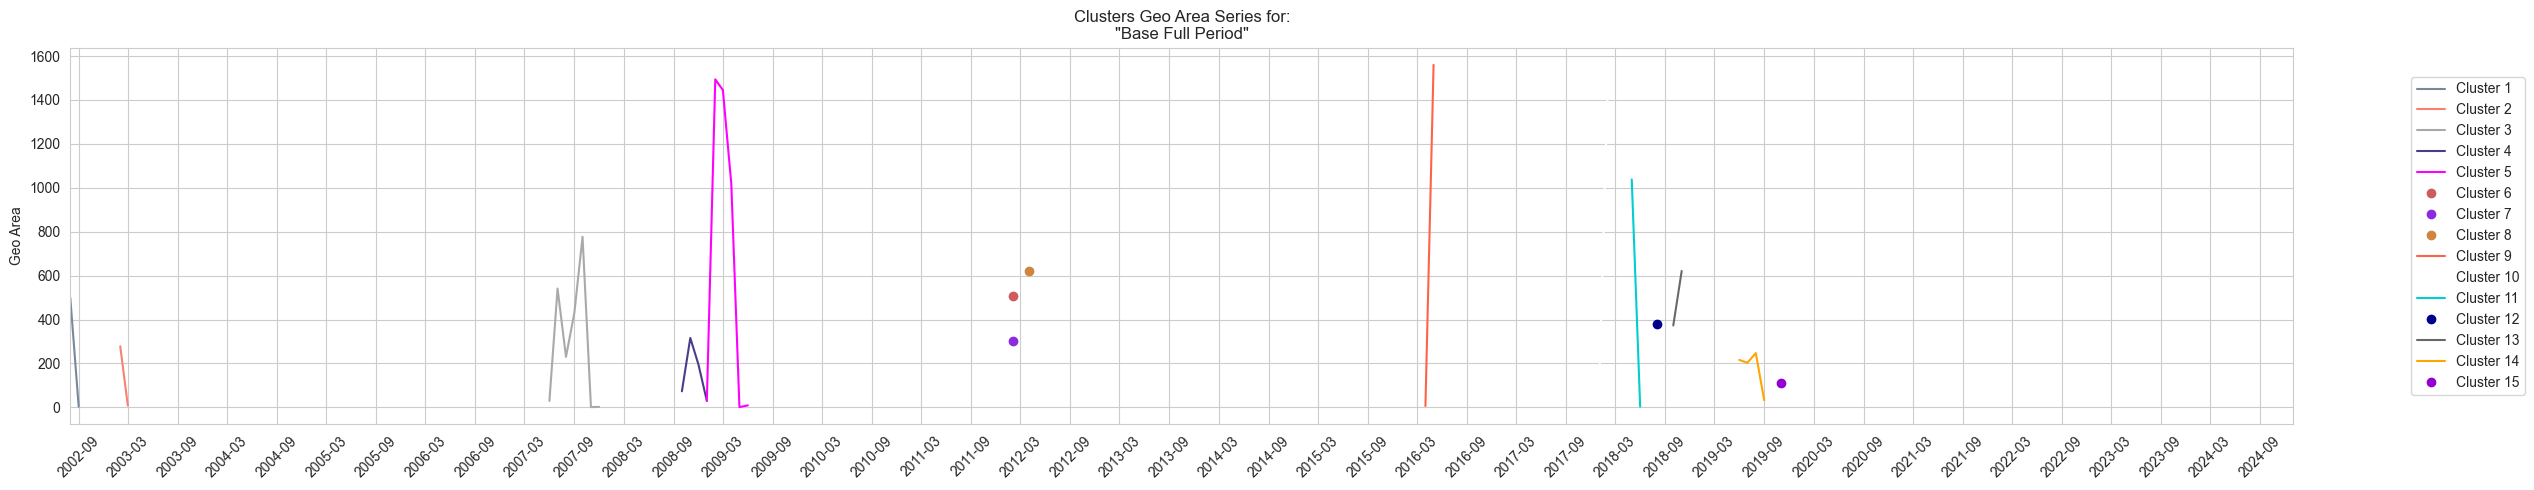

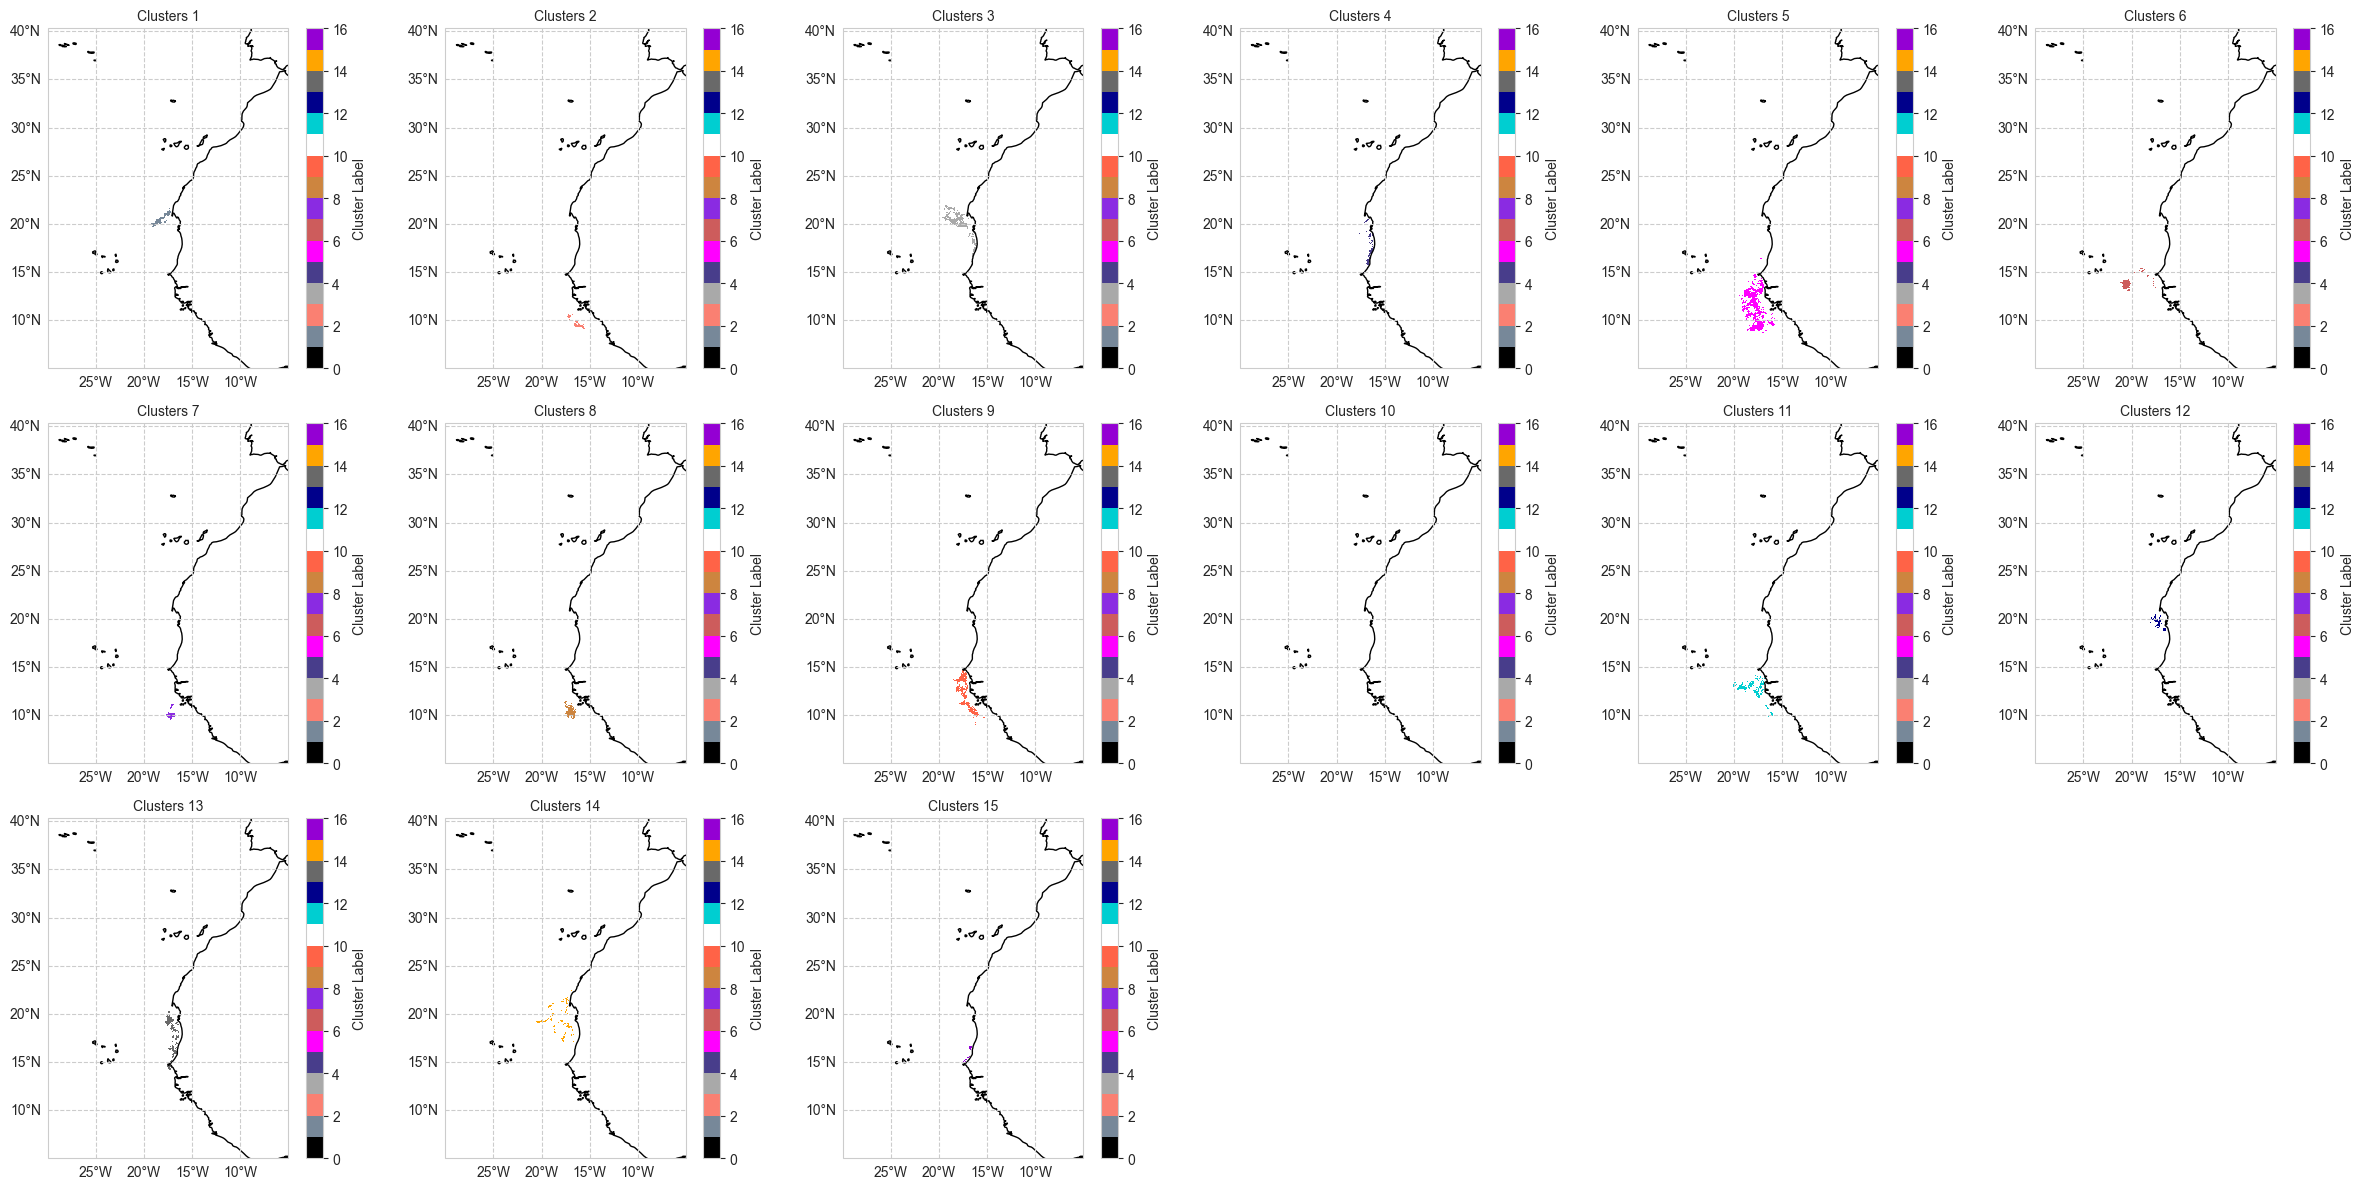

Experiment: Smaller Min Neighbors


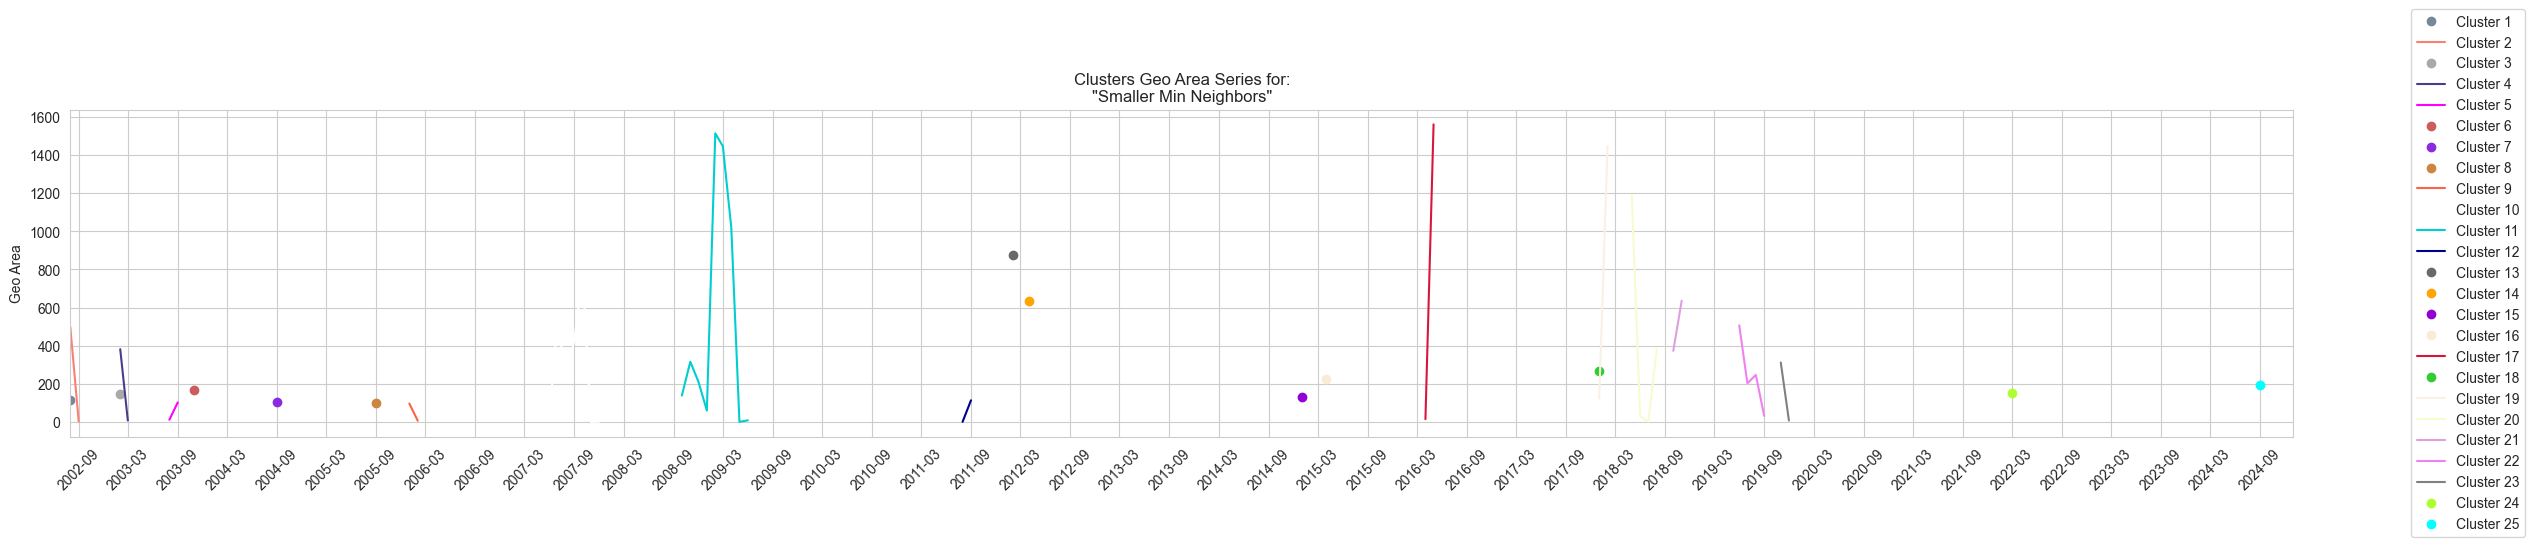

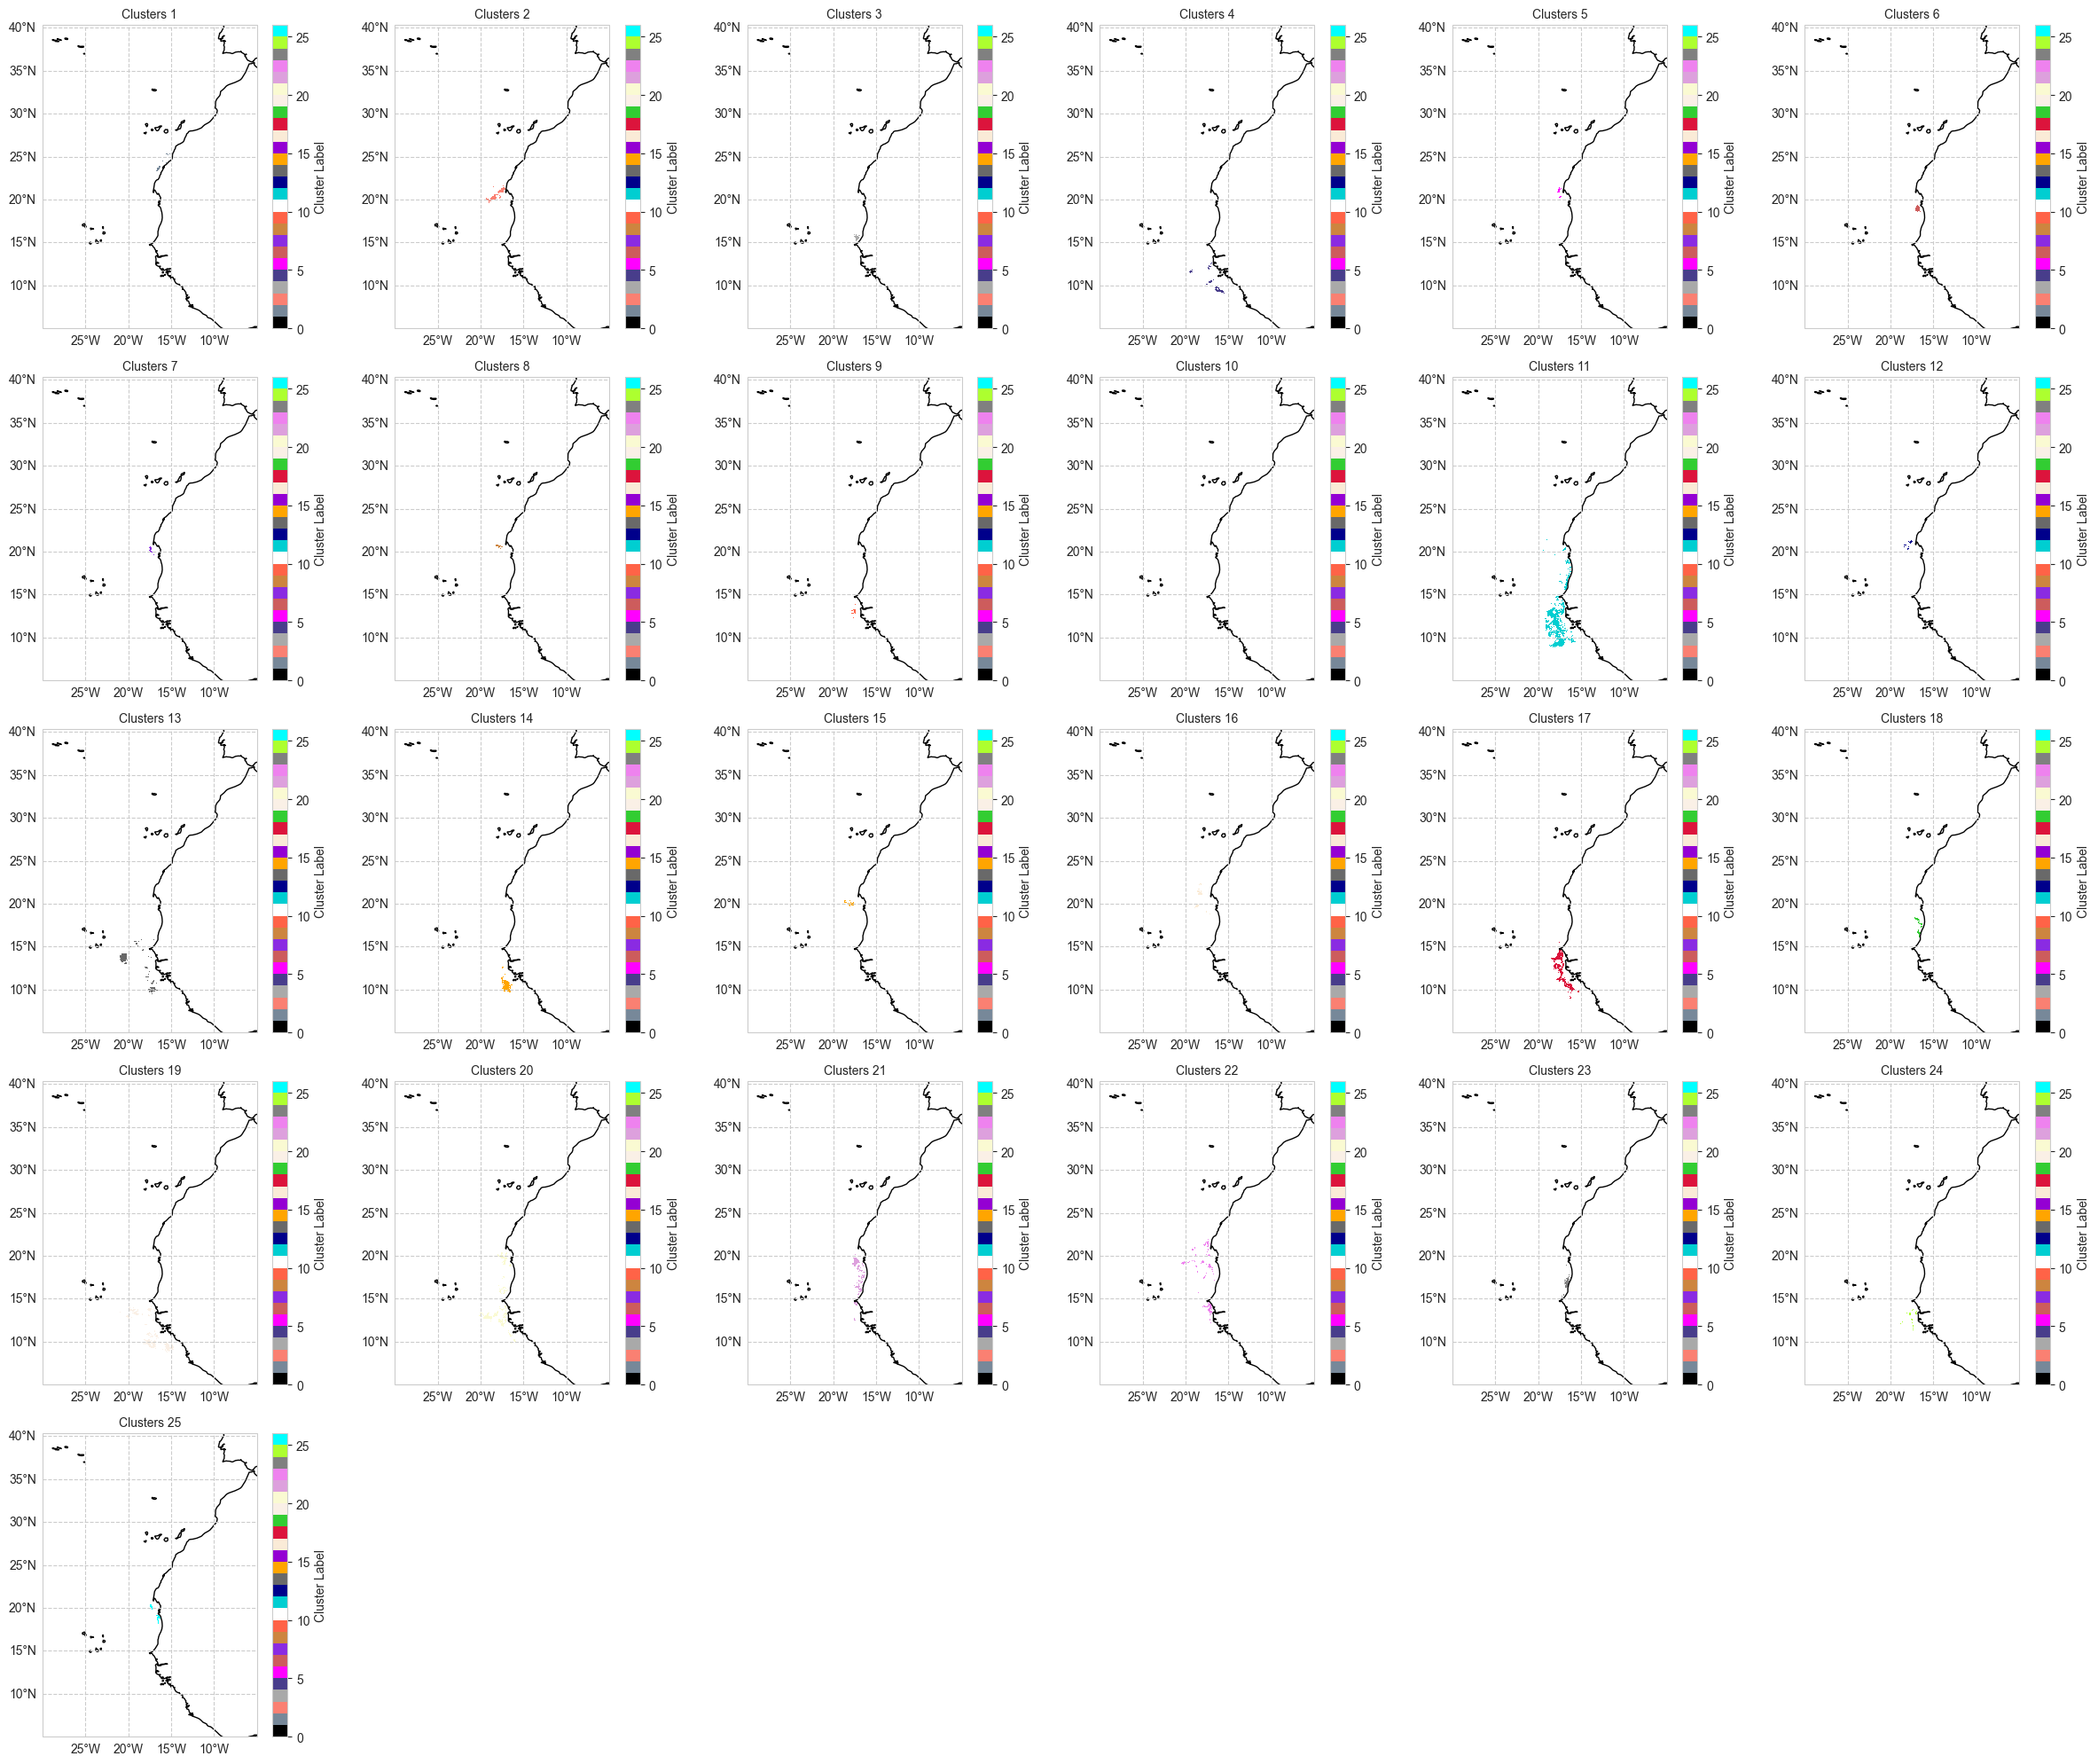

Experiment: Larger Min Neighbors


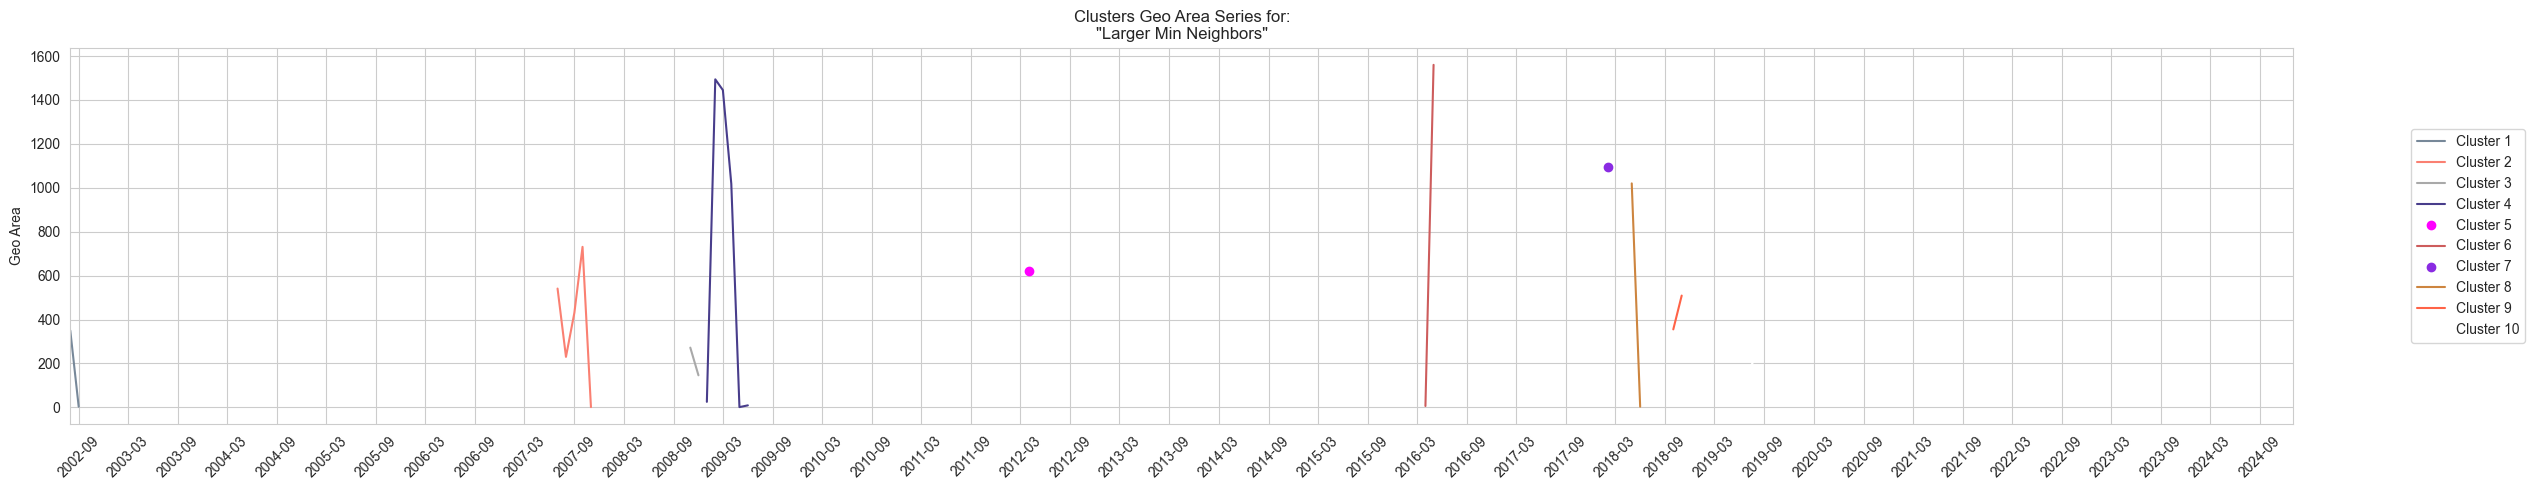

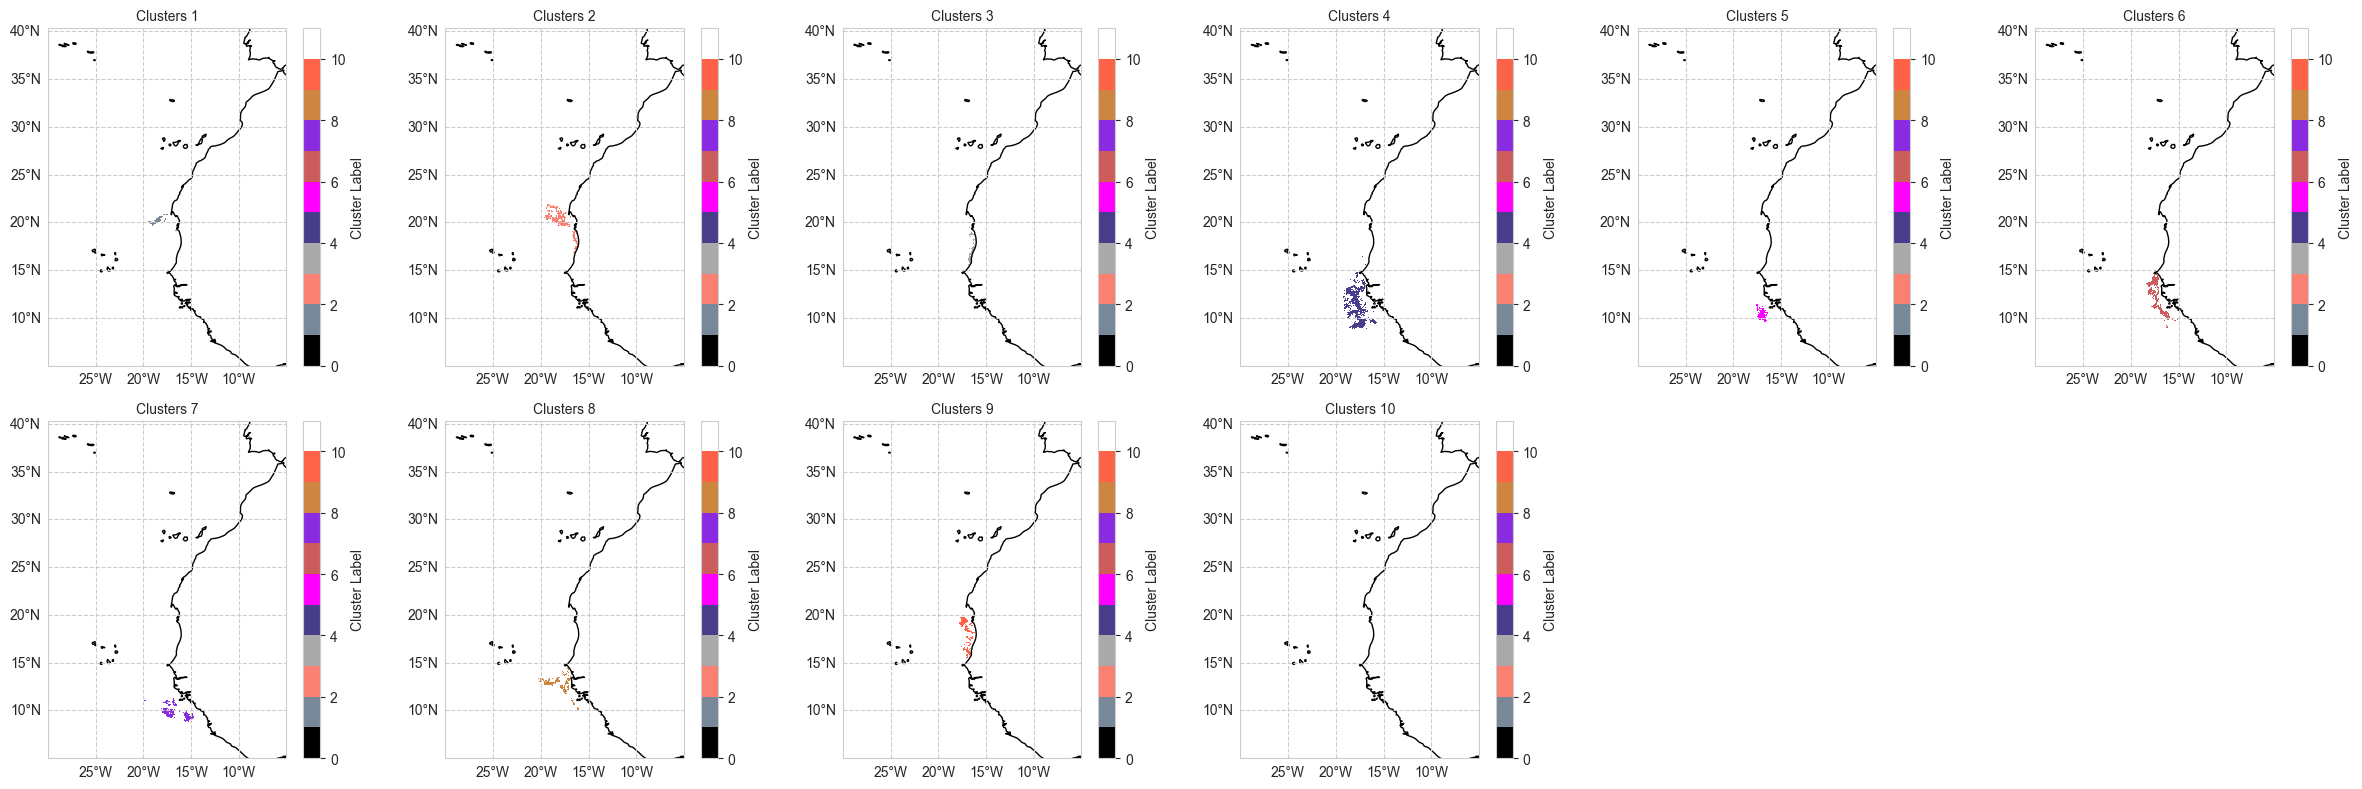

Experiment: Much Larger Min Neighbors


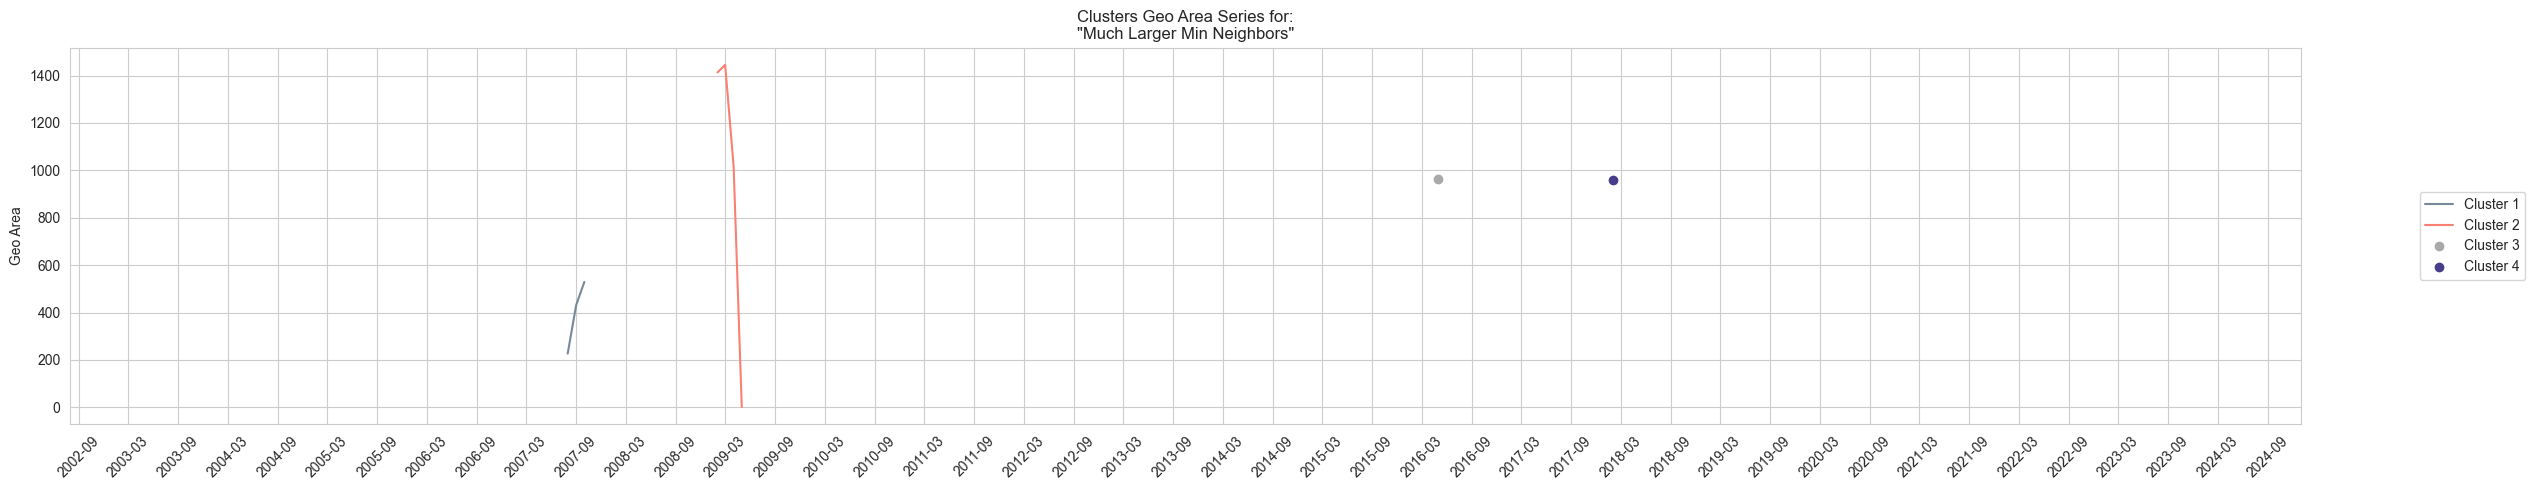

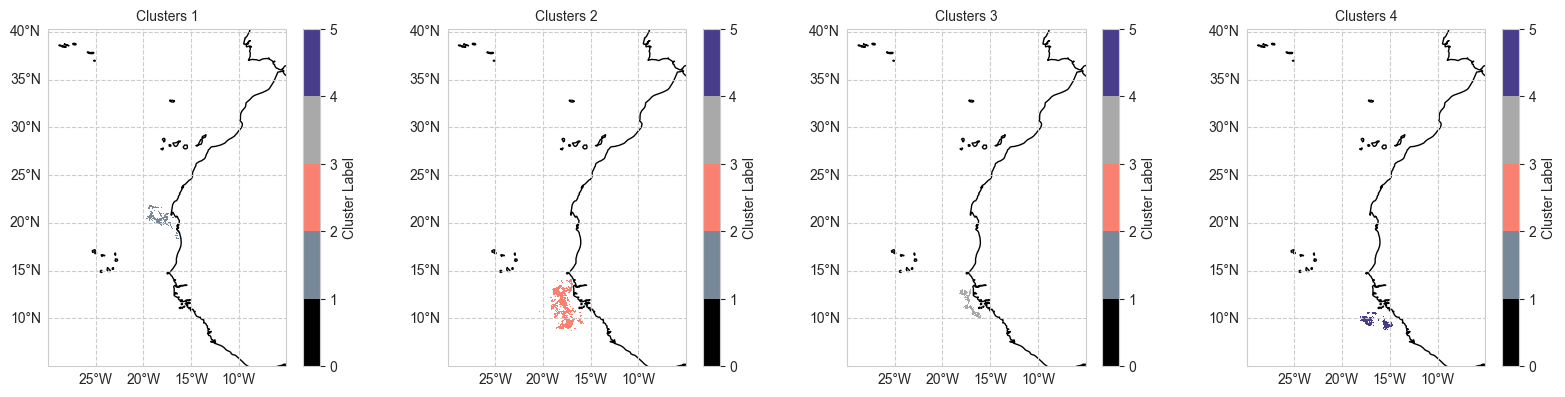

Experiment: Smaller Geo Eps


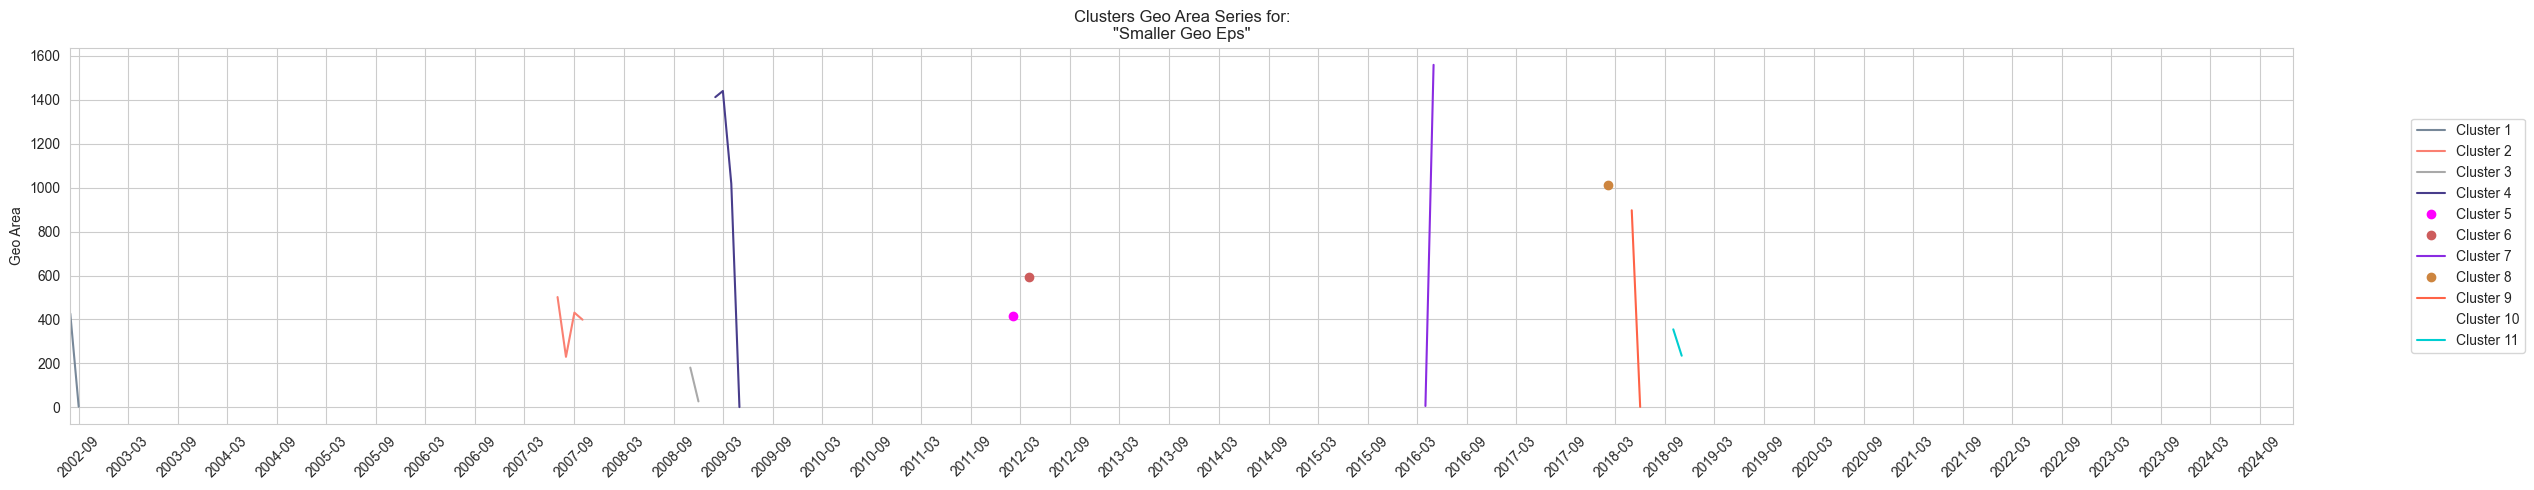

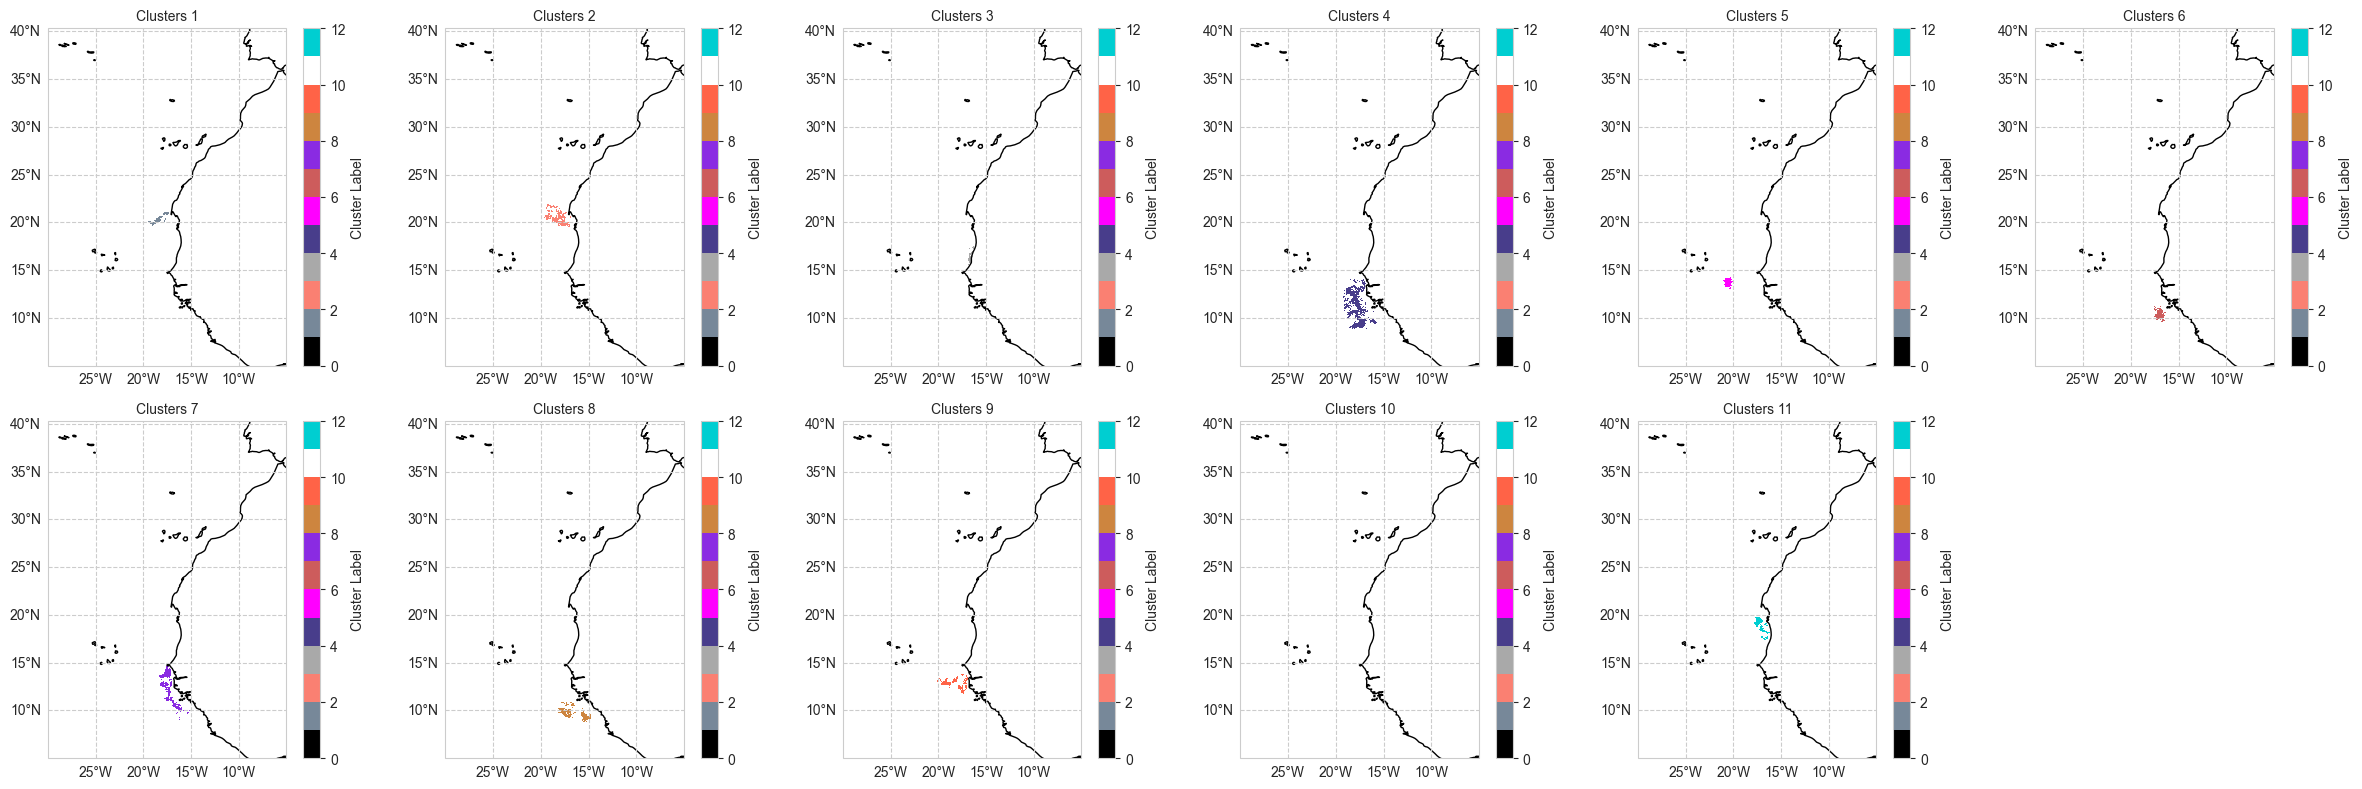

Experiment: Larger Geo Eps


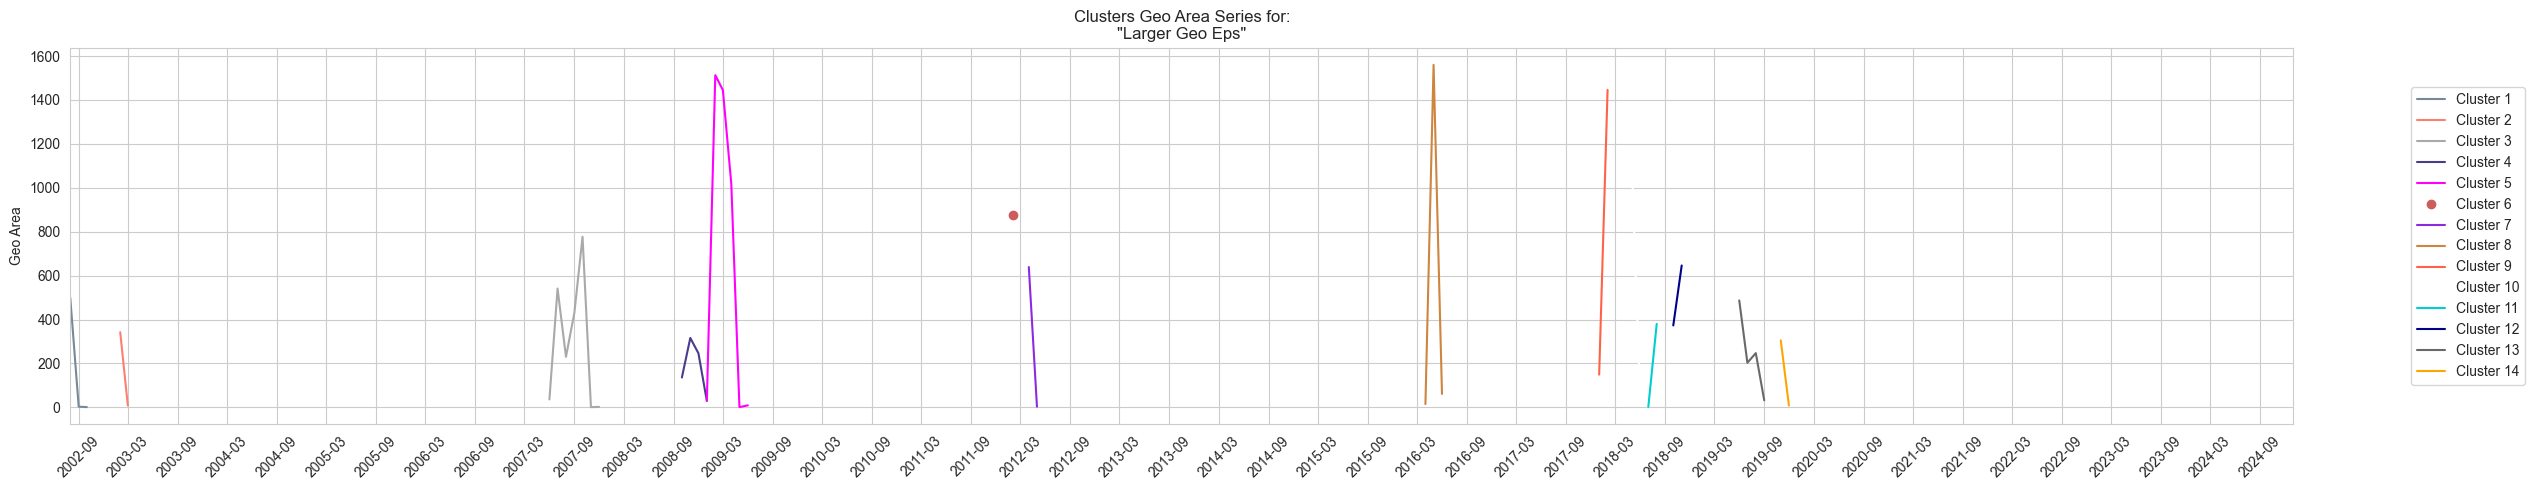

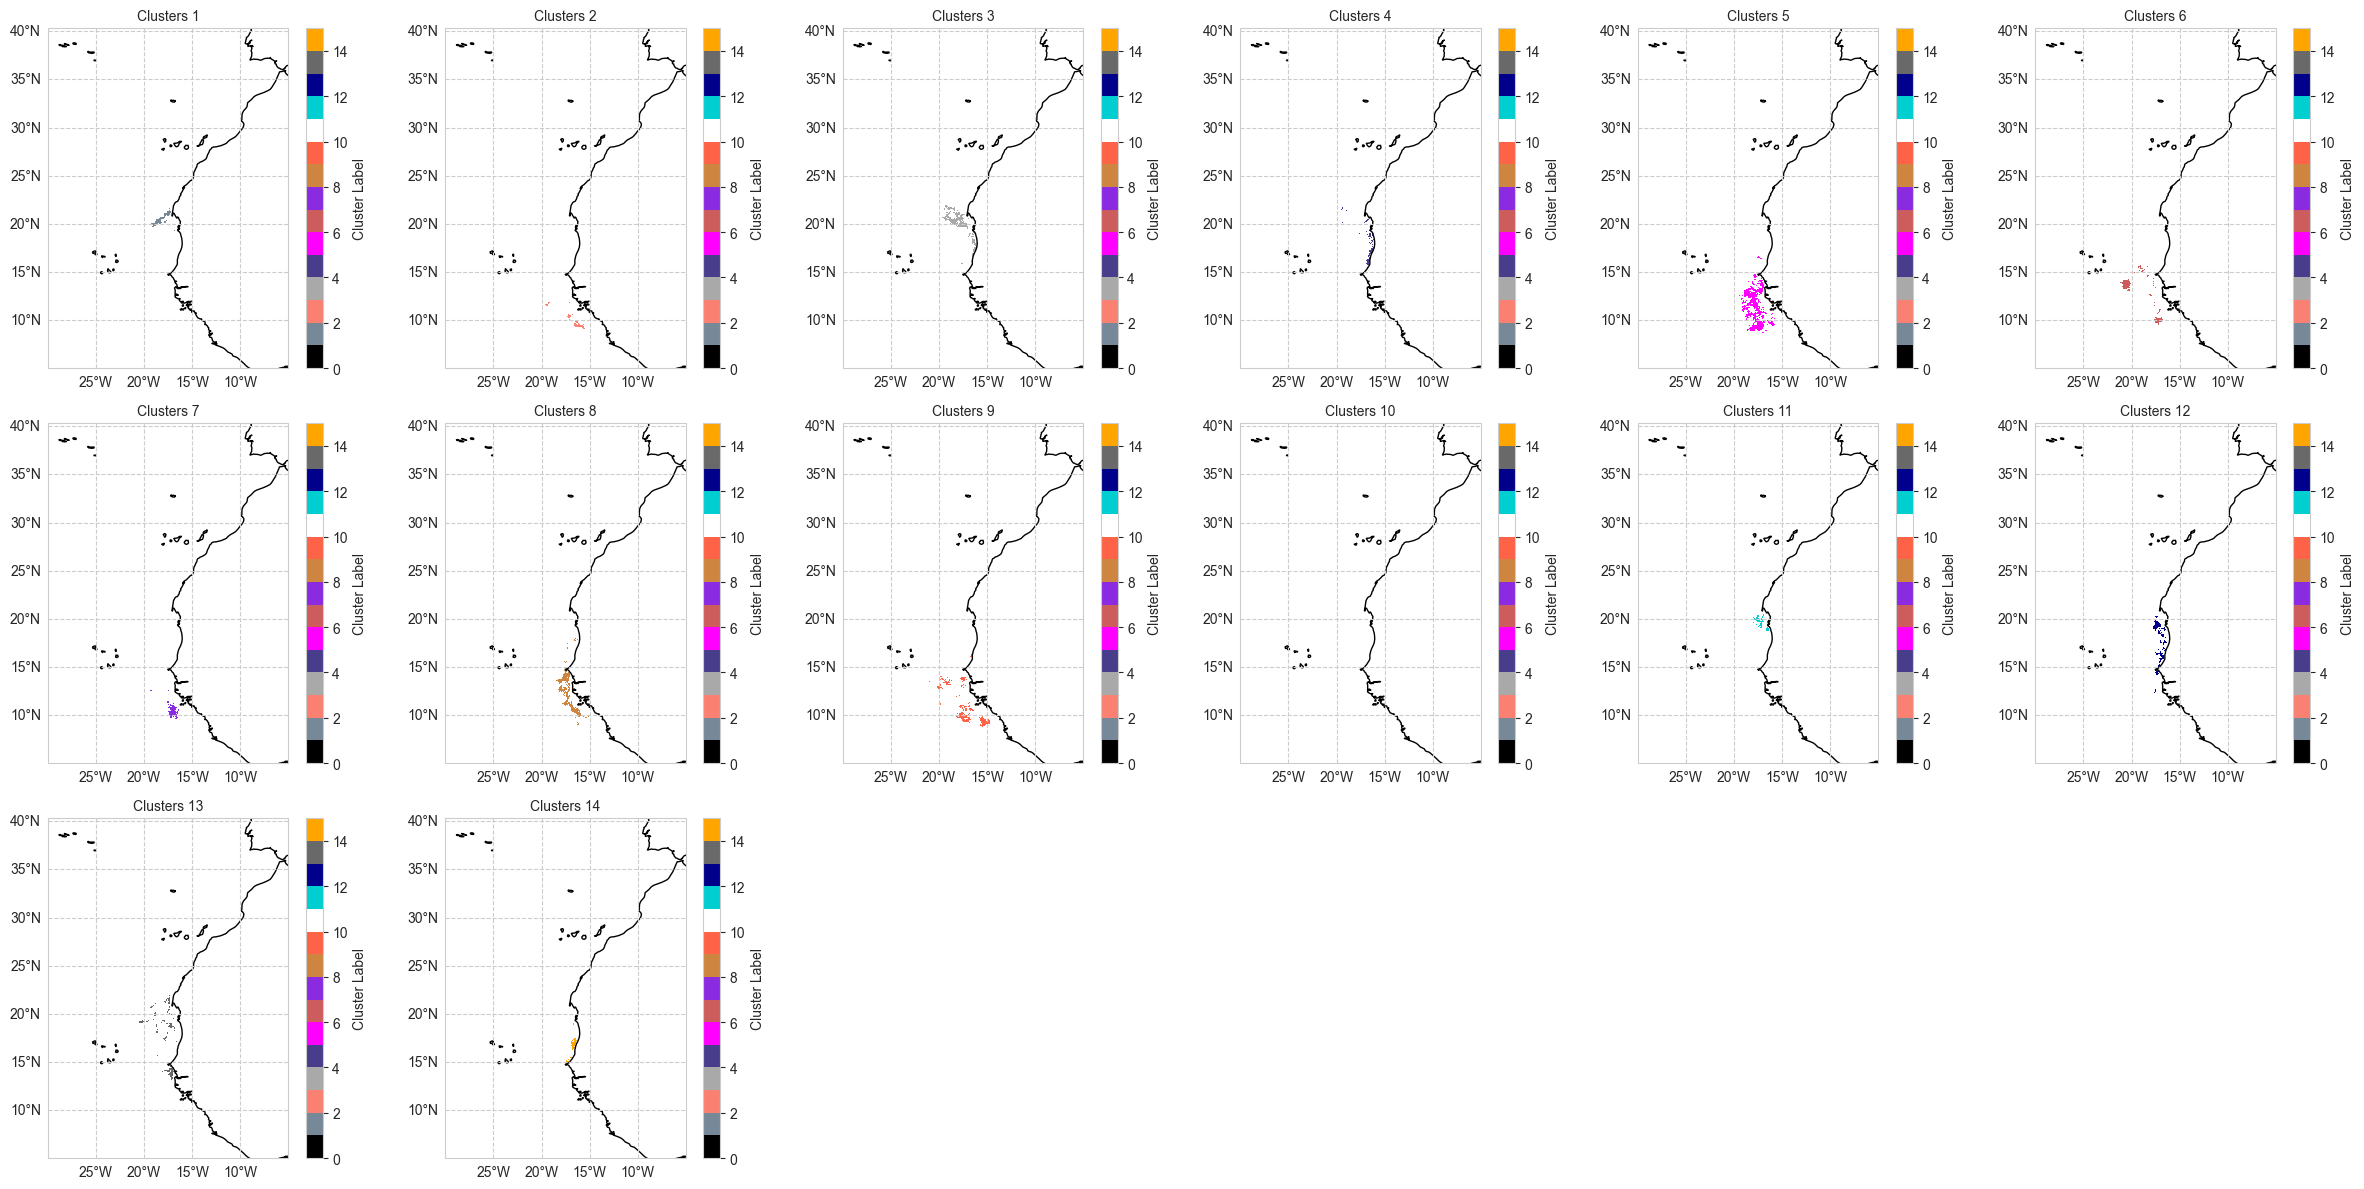

Experiment: Larger Time Eps


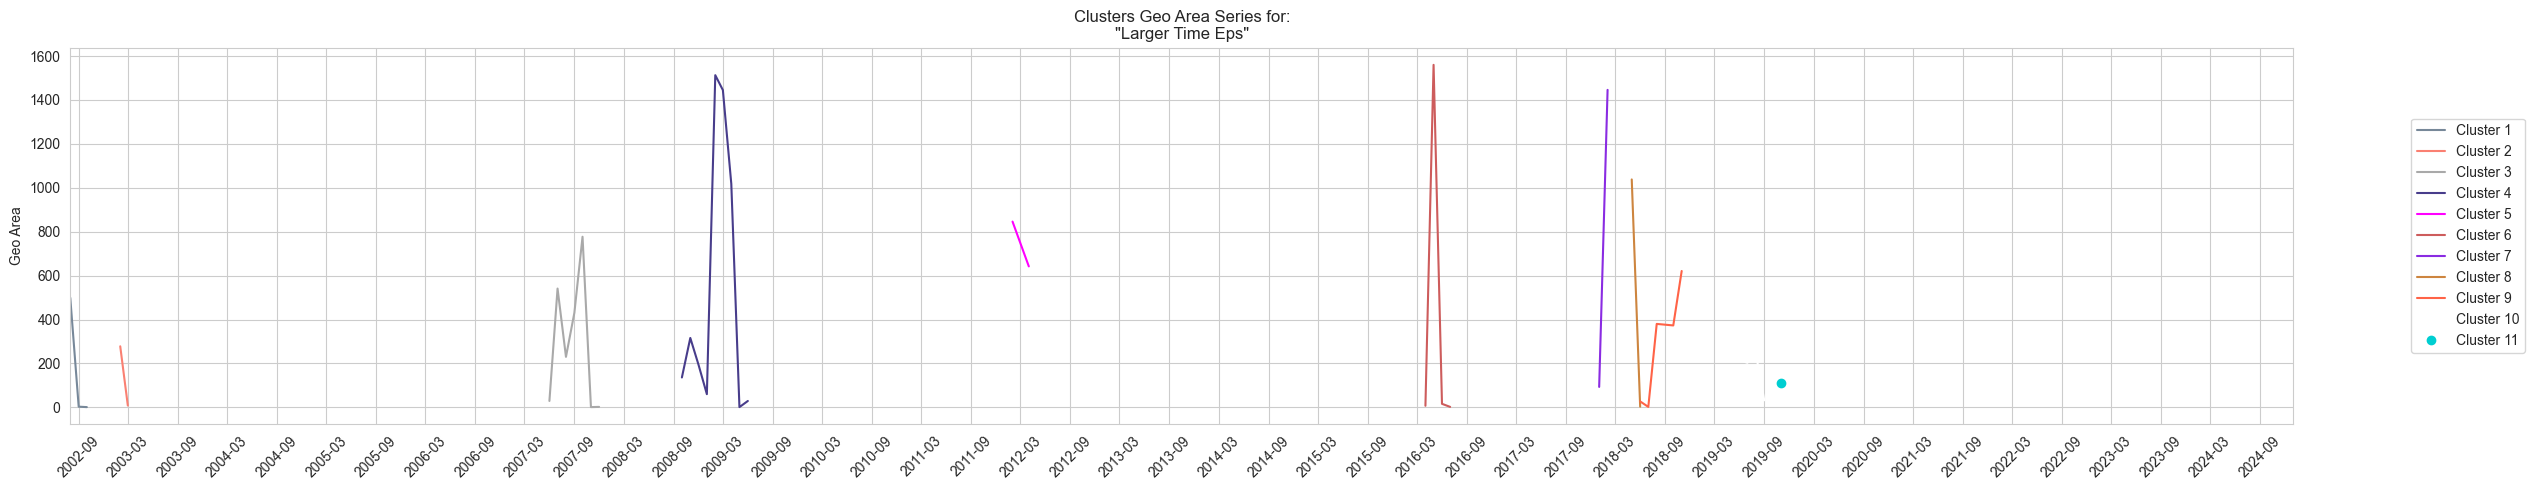

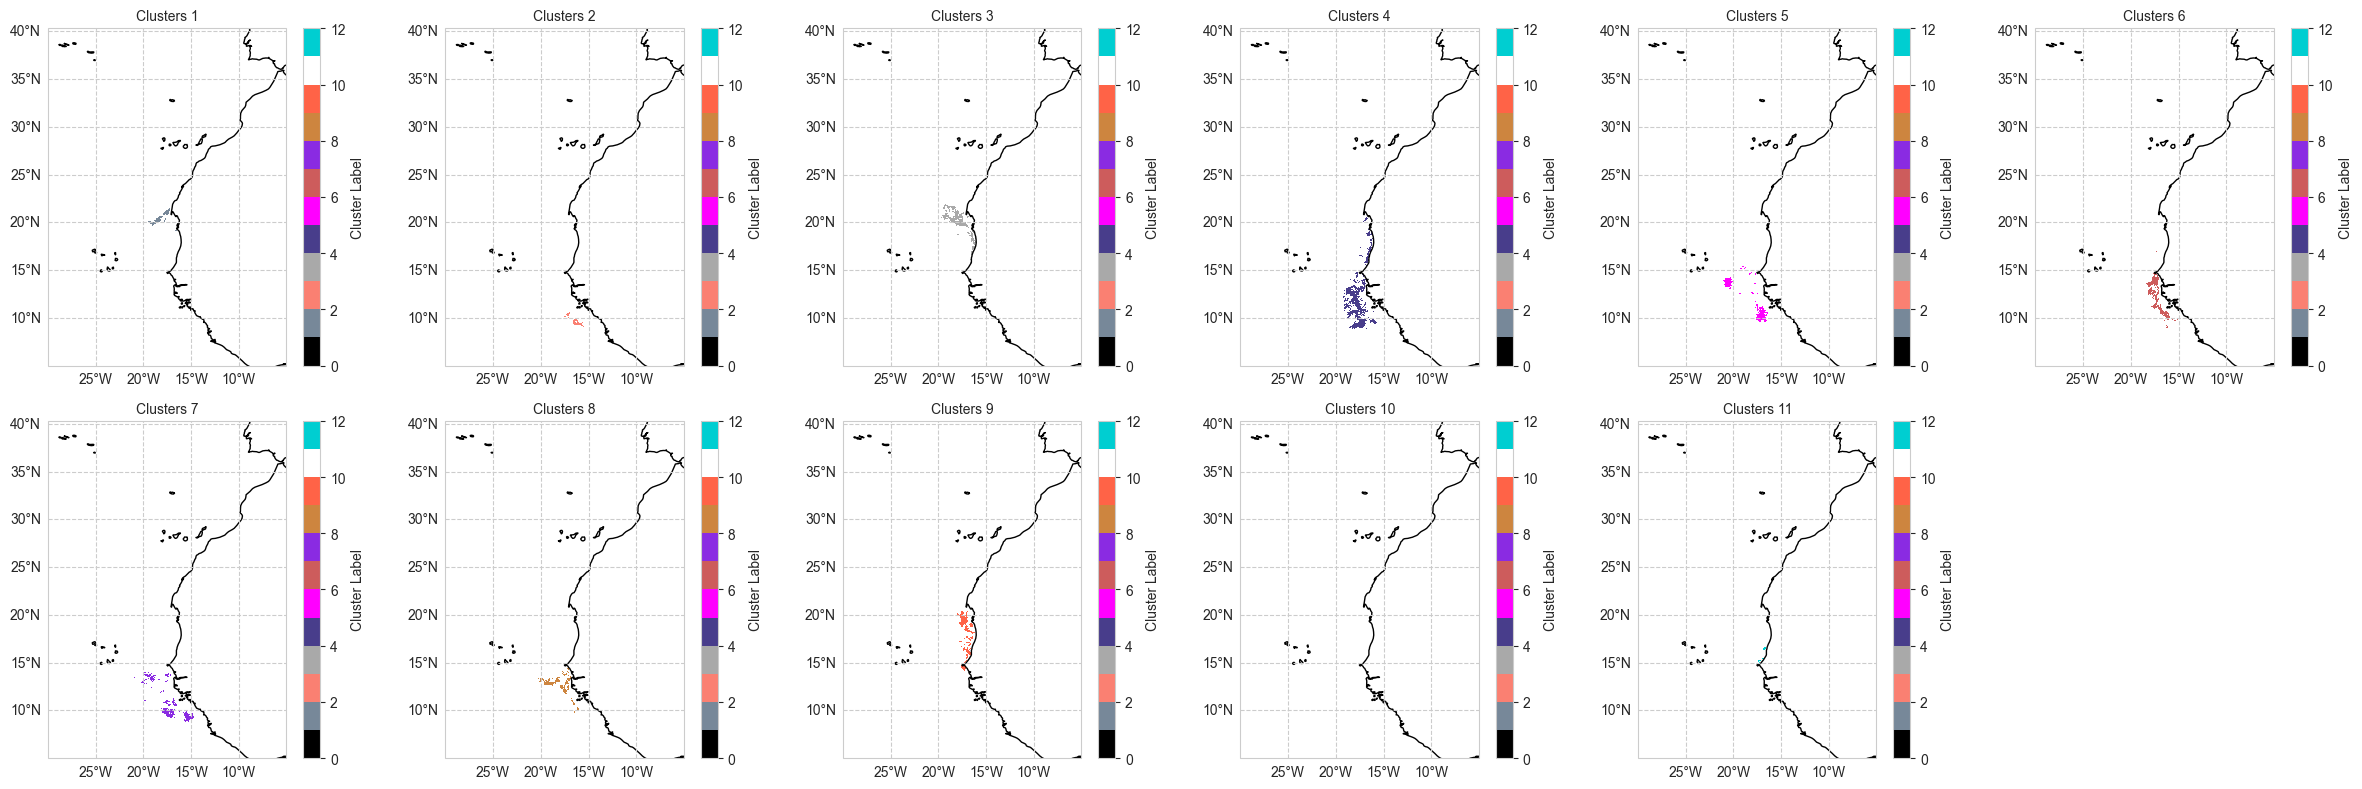

Experiment: Much Larger Time Eps


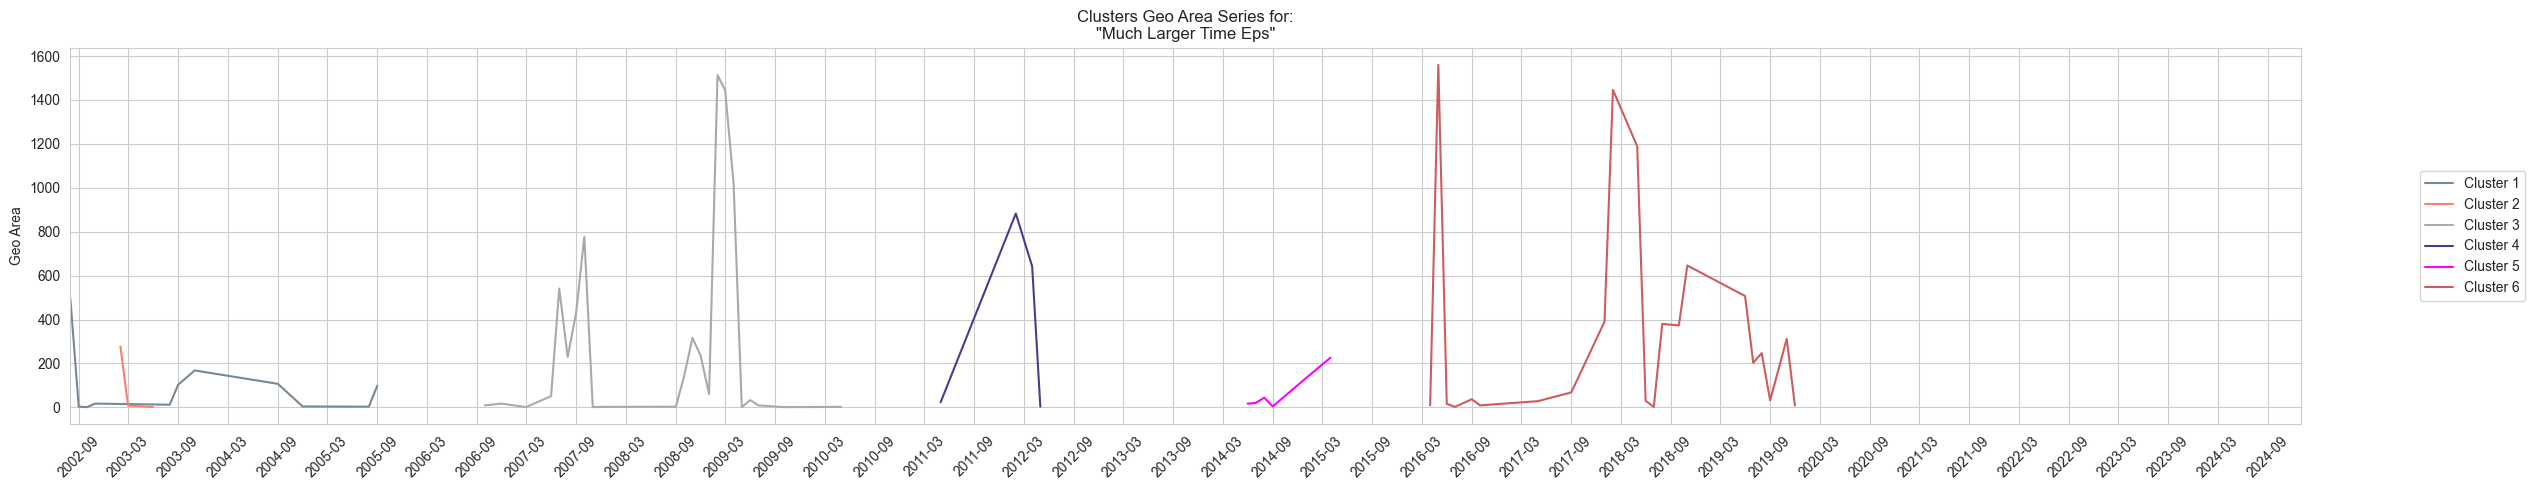

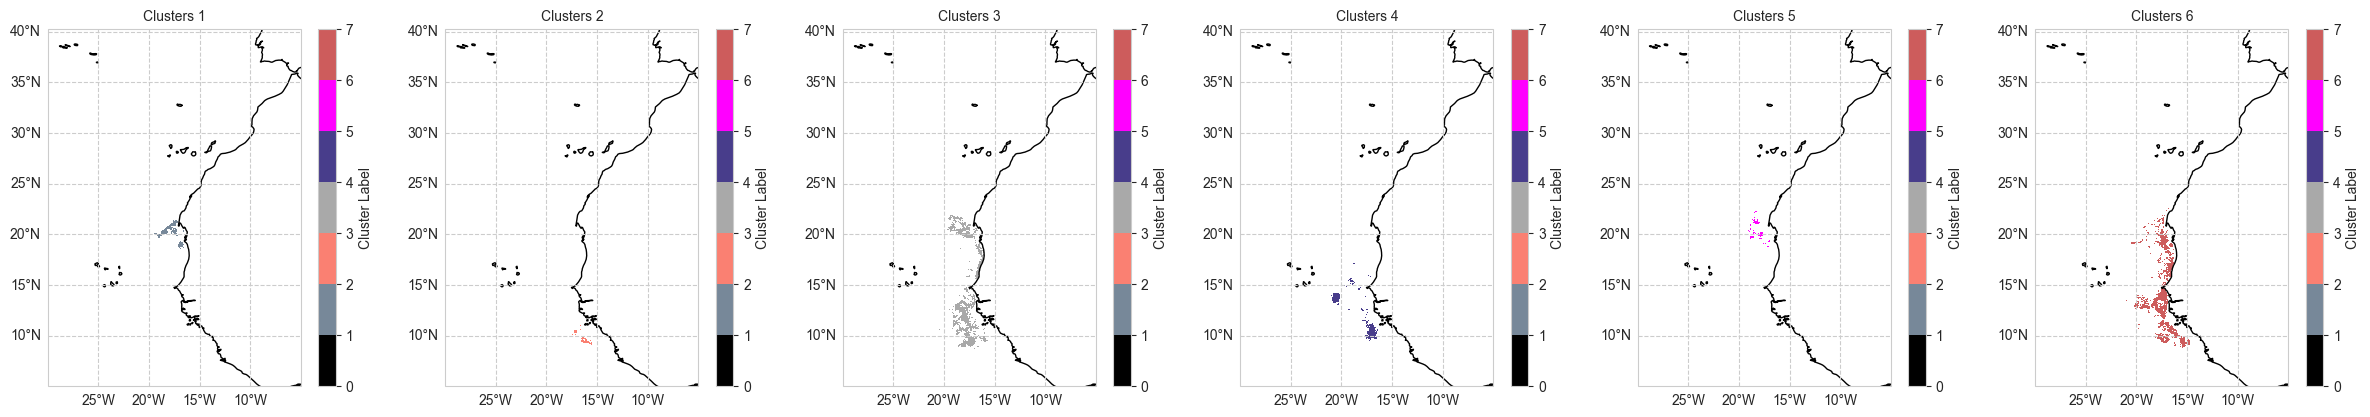

In [156]:
for experiment in experiment_results:
    clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name = experiment
    print(f"Experiment: {experiment_name}")
    
    # Plot the time series of all clusters
    plot_cluster_geo_area_series(clusters, n_clusters, experiment_name)

    # Plot overlay of each cluster in experiment
    plot_individual_cluster_overlay(clusters, n_clusters, experiment_name)

##### Second Batch

Experiment: (2) Base Full Period


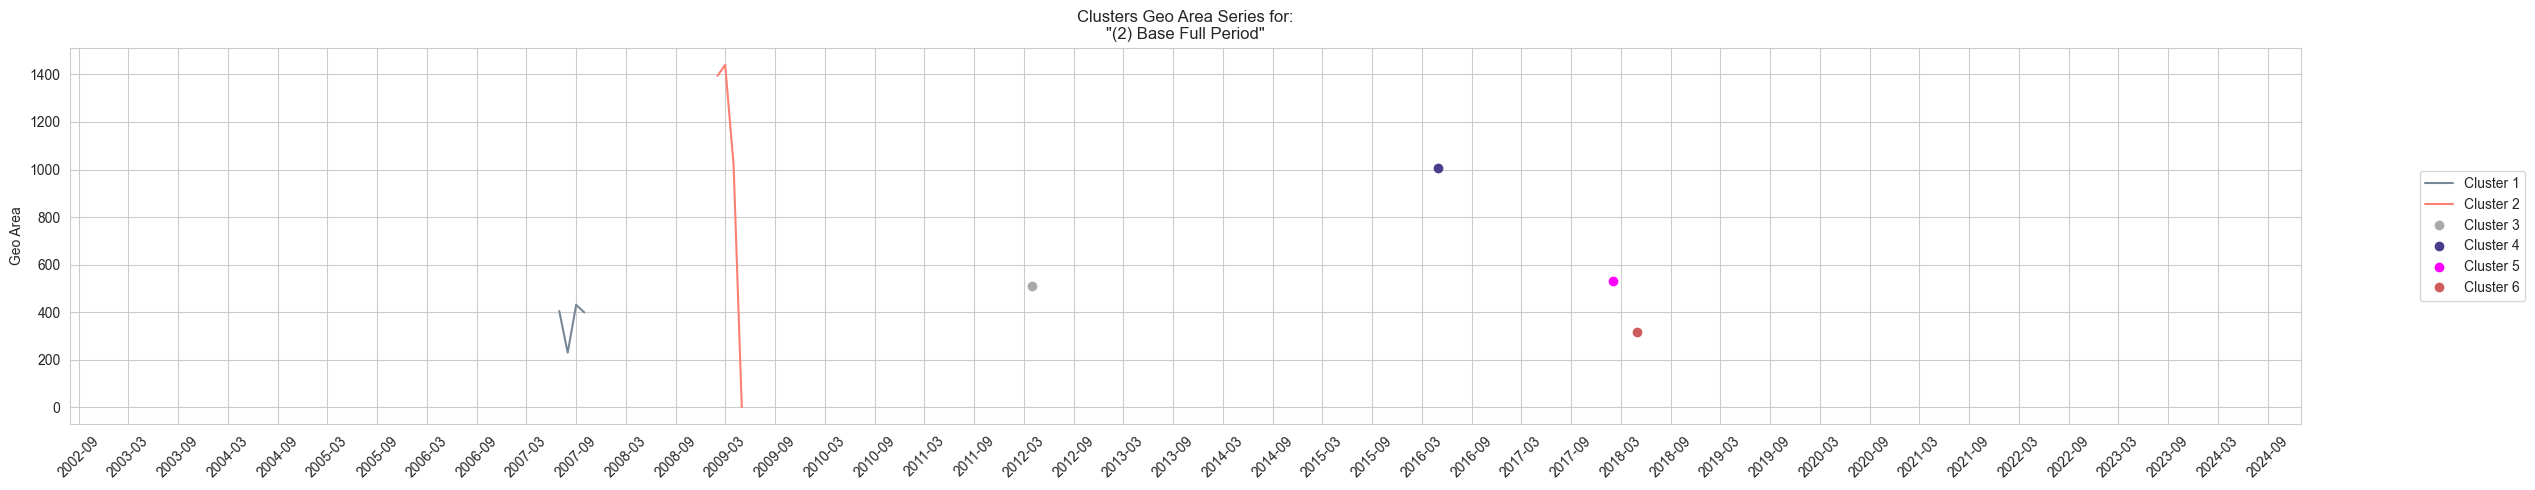

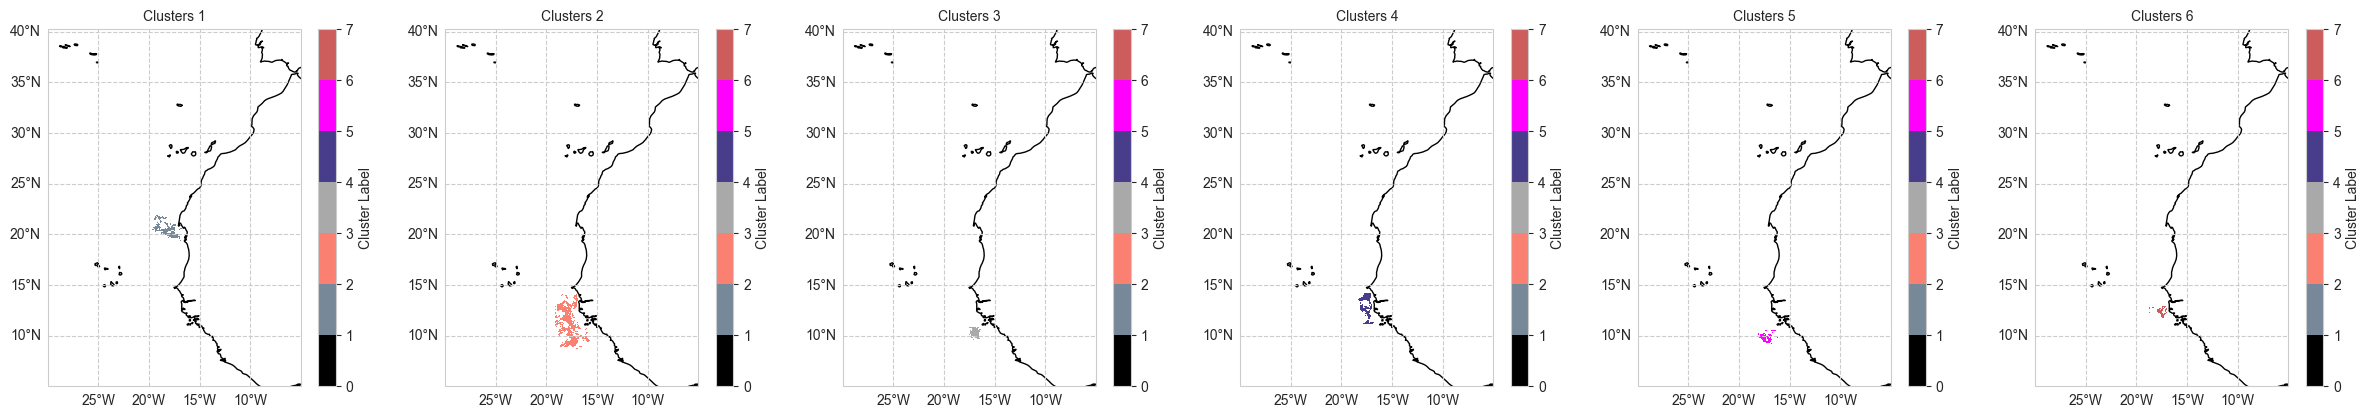

Experiment: (2) Smaller Min Neighbors


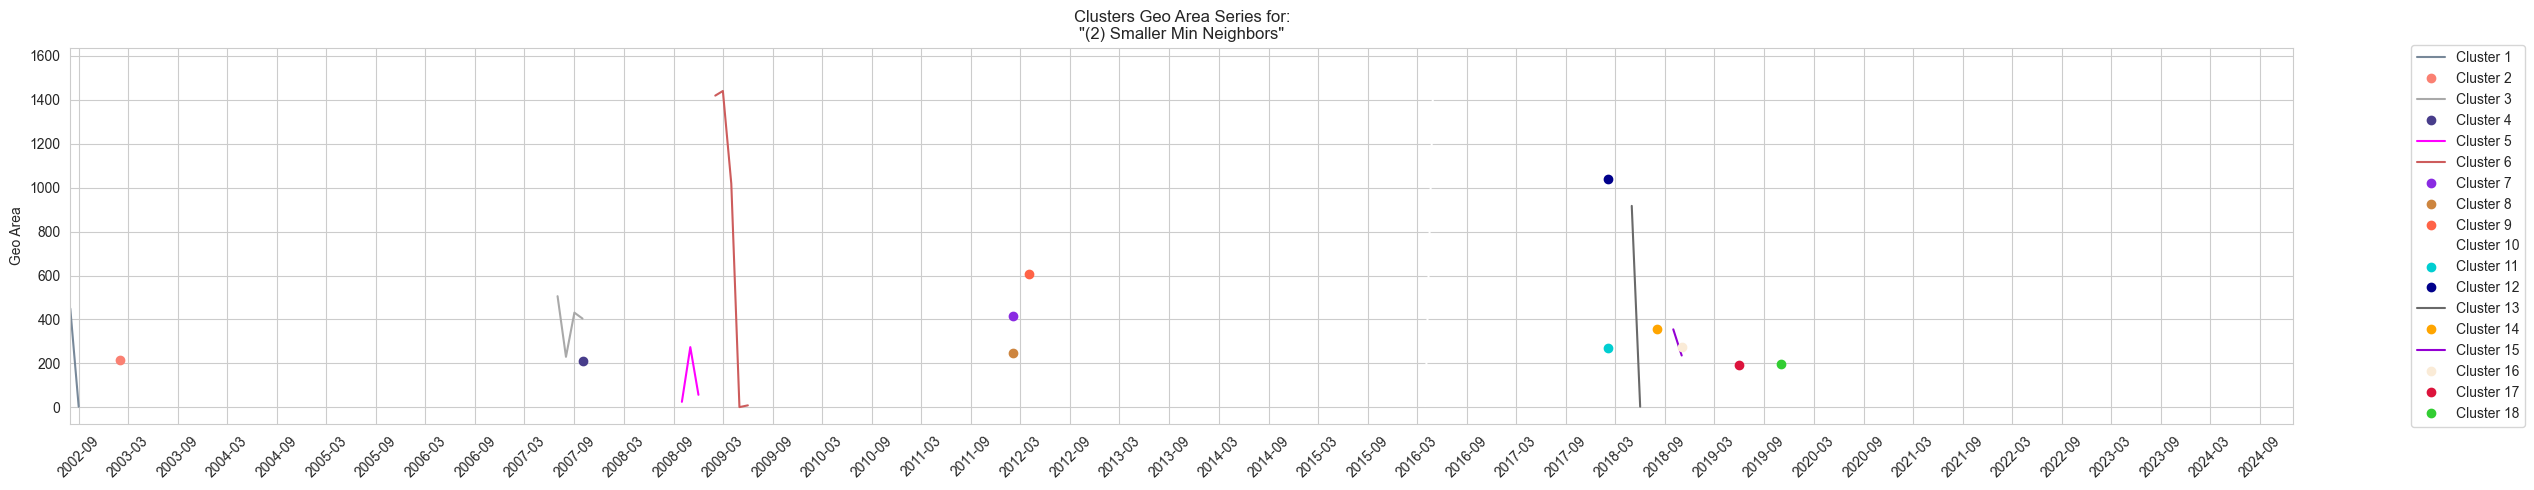

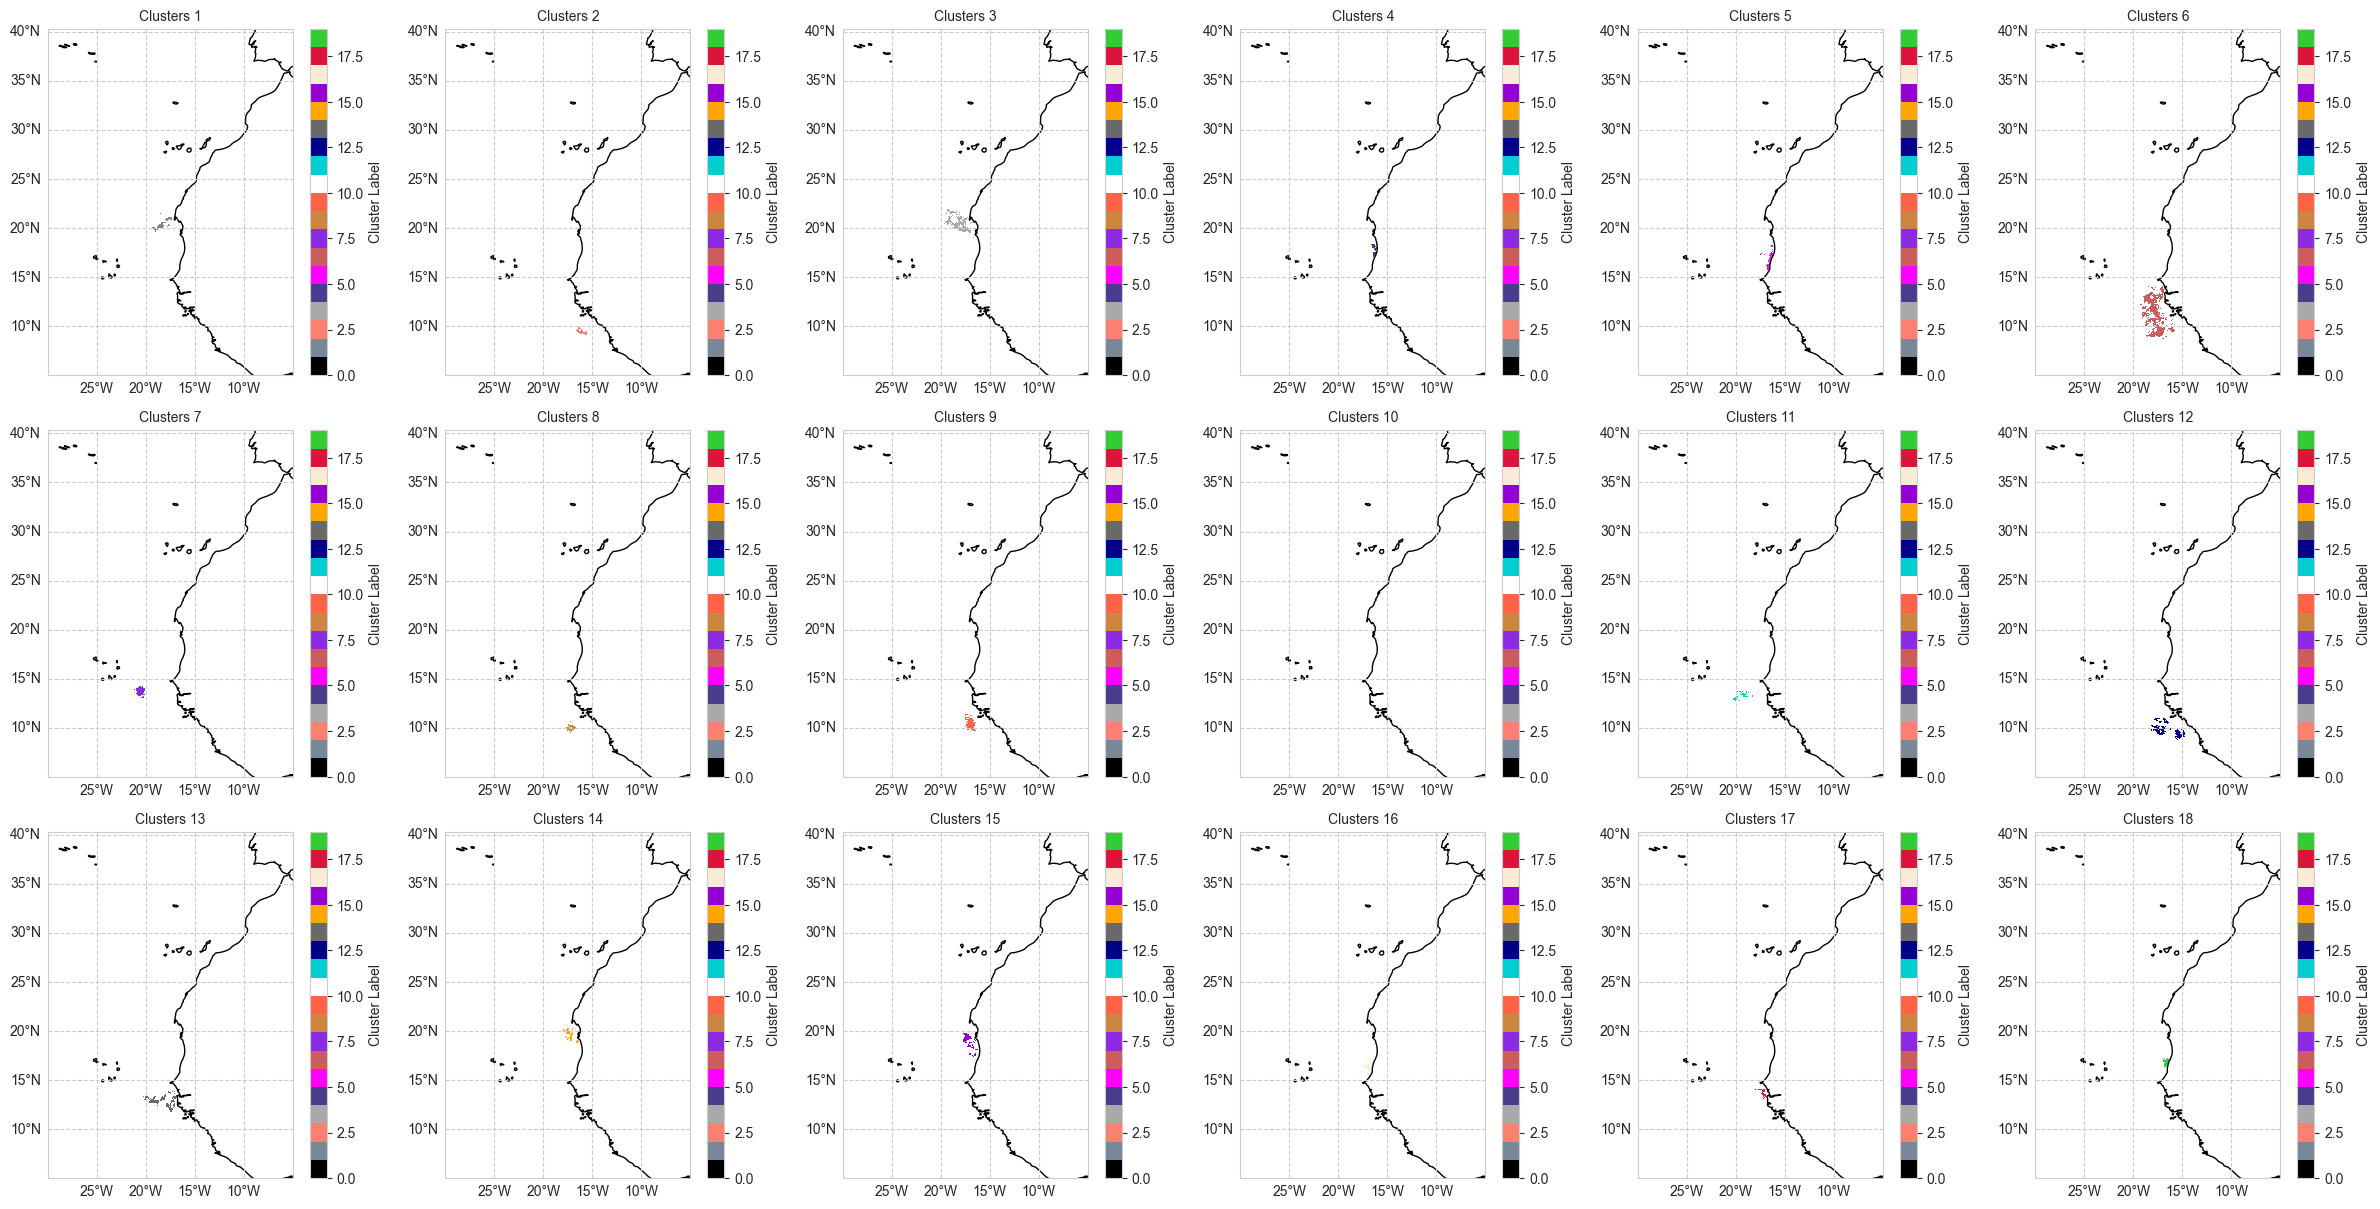

Experiment: (2) Larger Min Neighbors


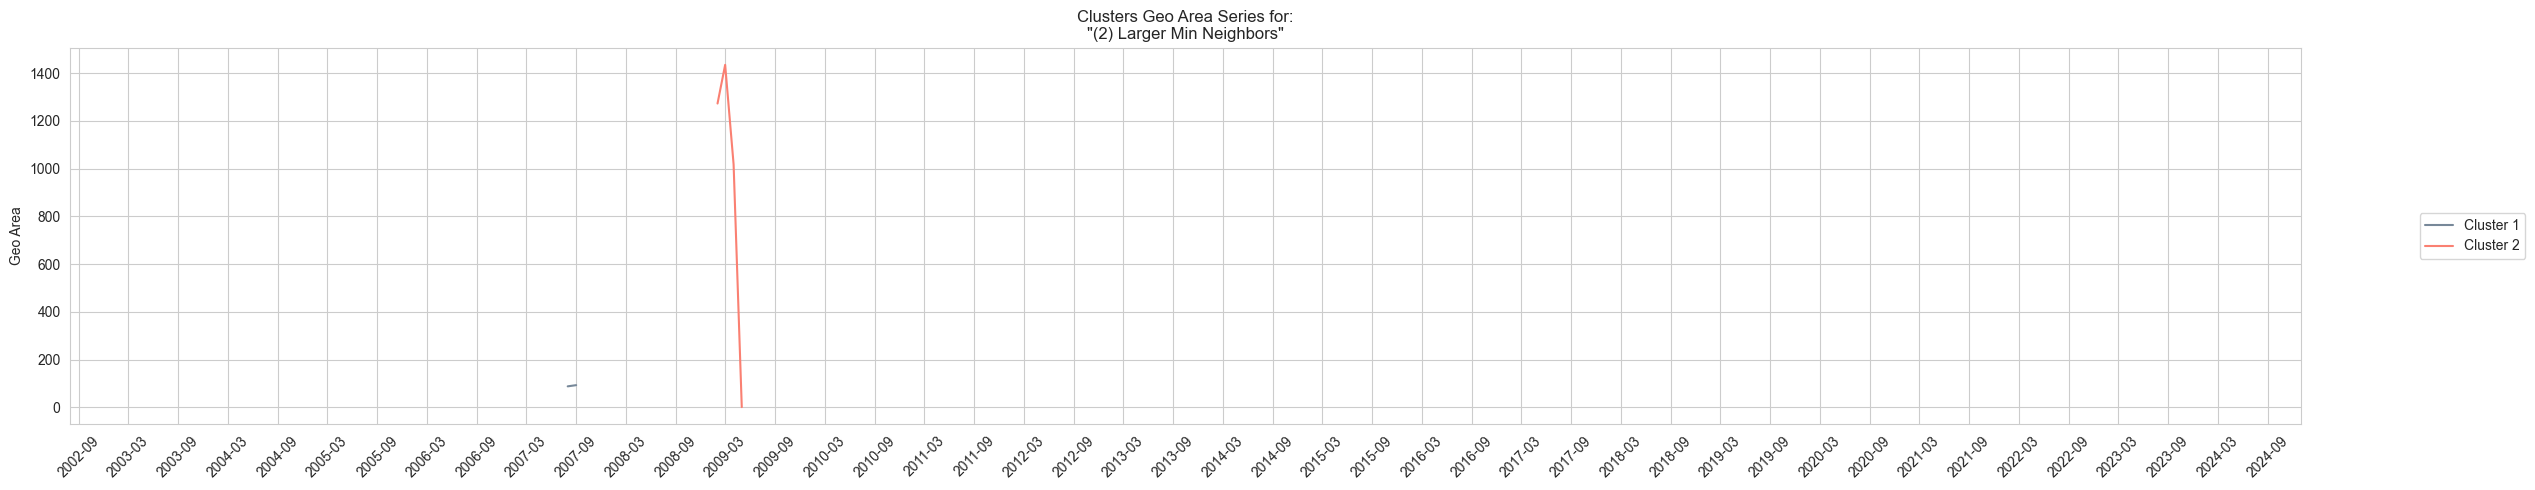

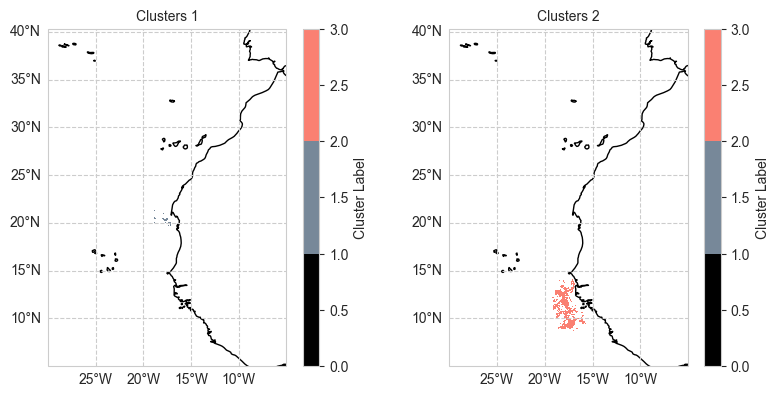

Experiment: (2) Much Larger Min Neighbors


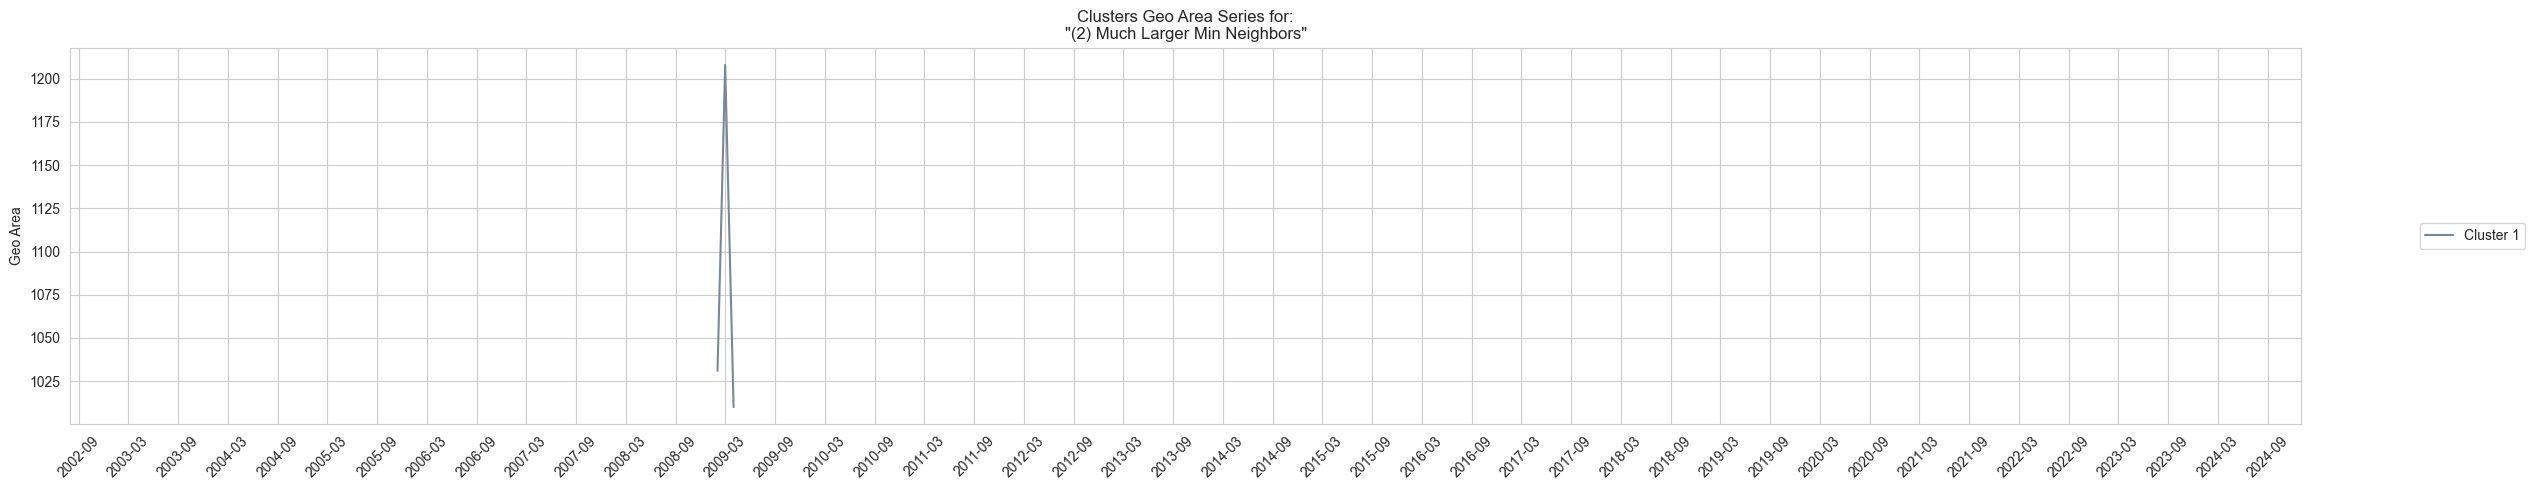

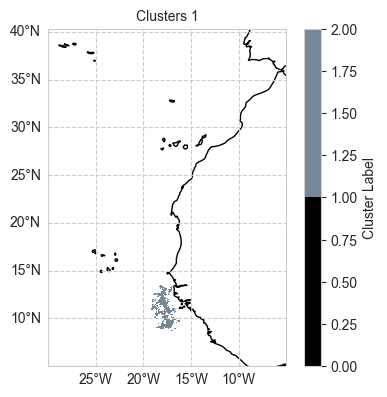

Experiment: (2) Smaller Geo Eps


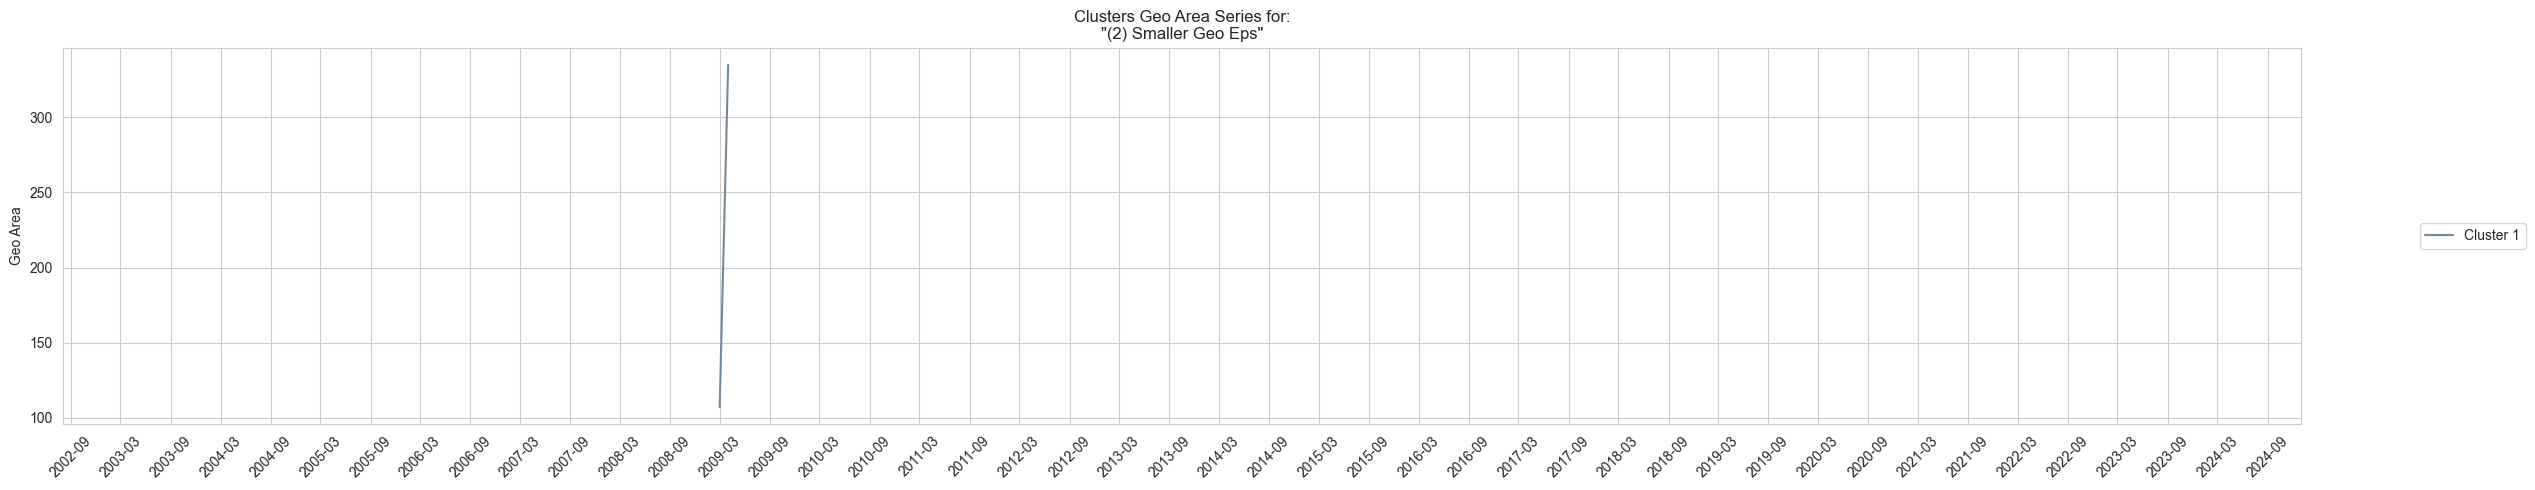

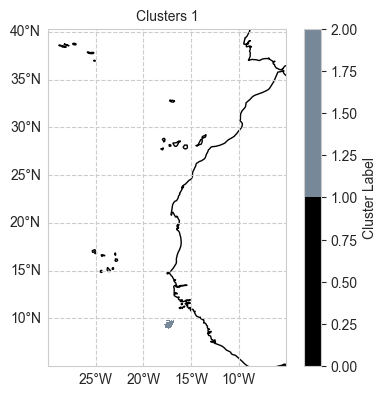

Experiment: (2) Larger Geo Eps


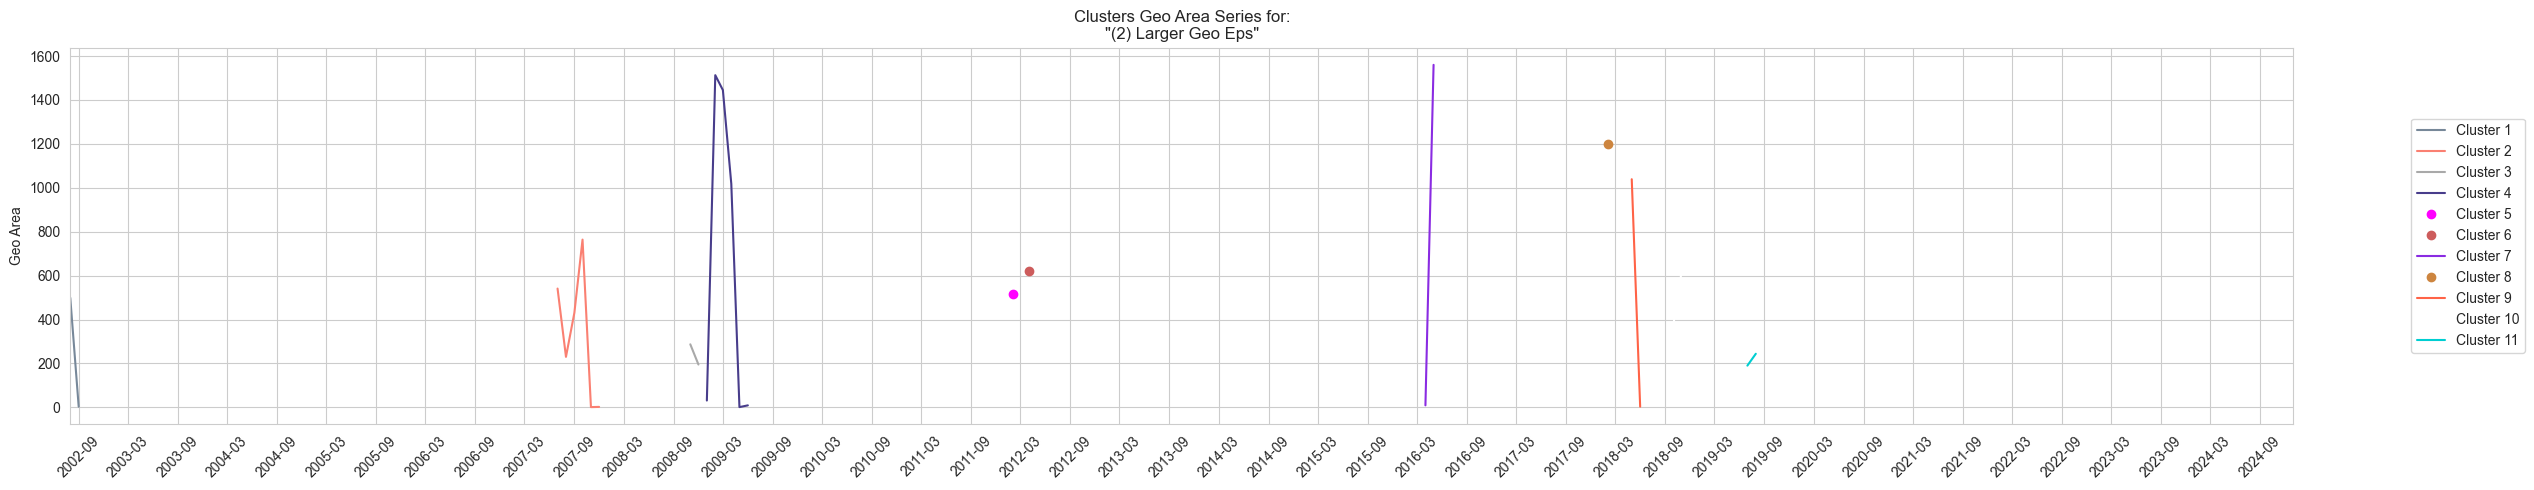

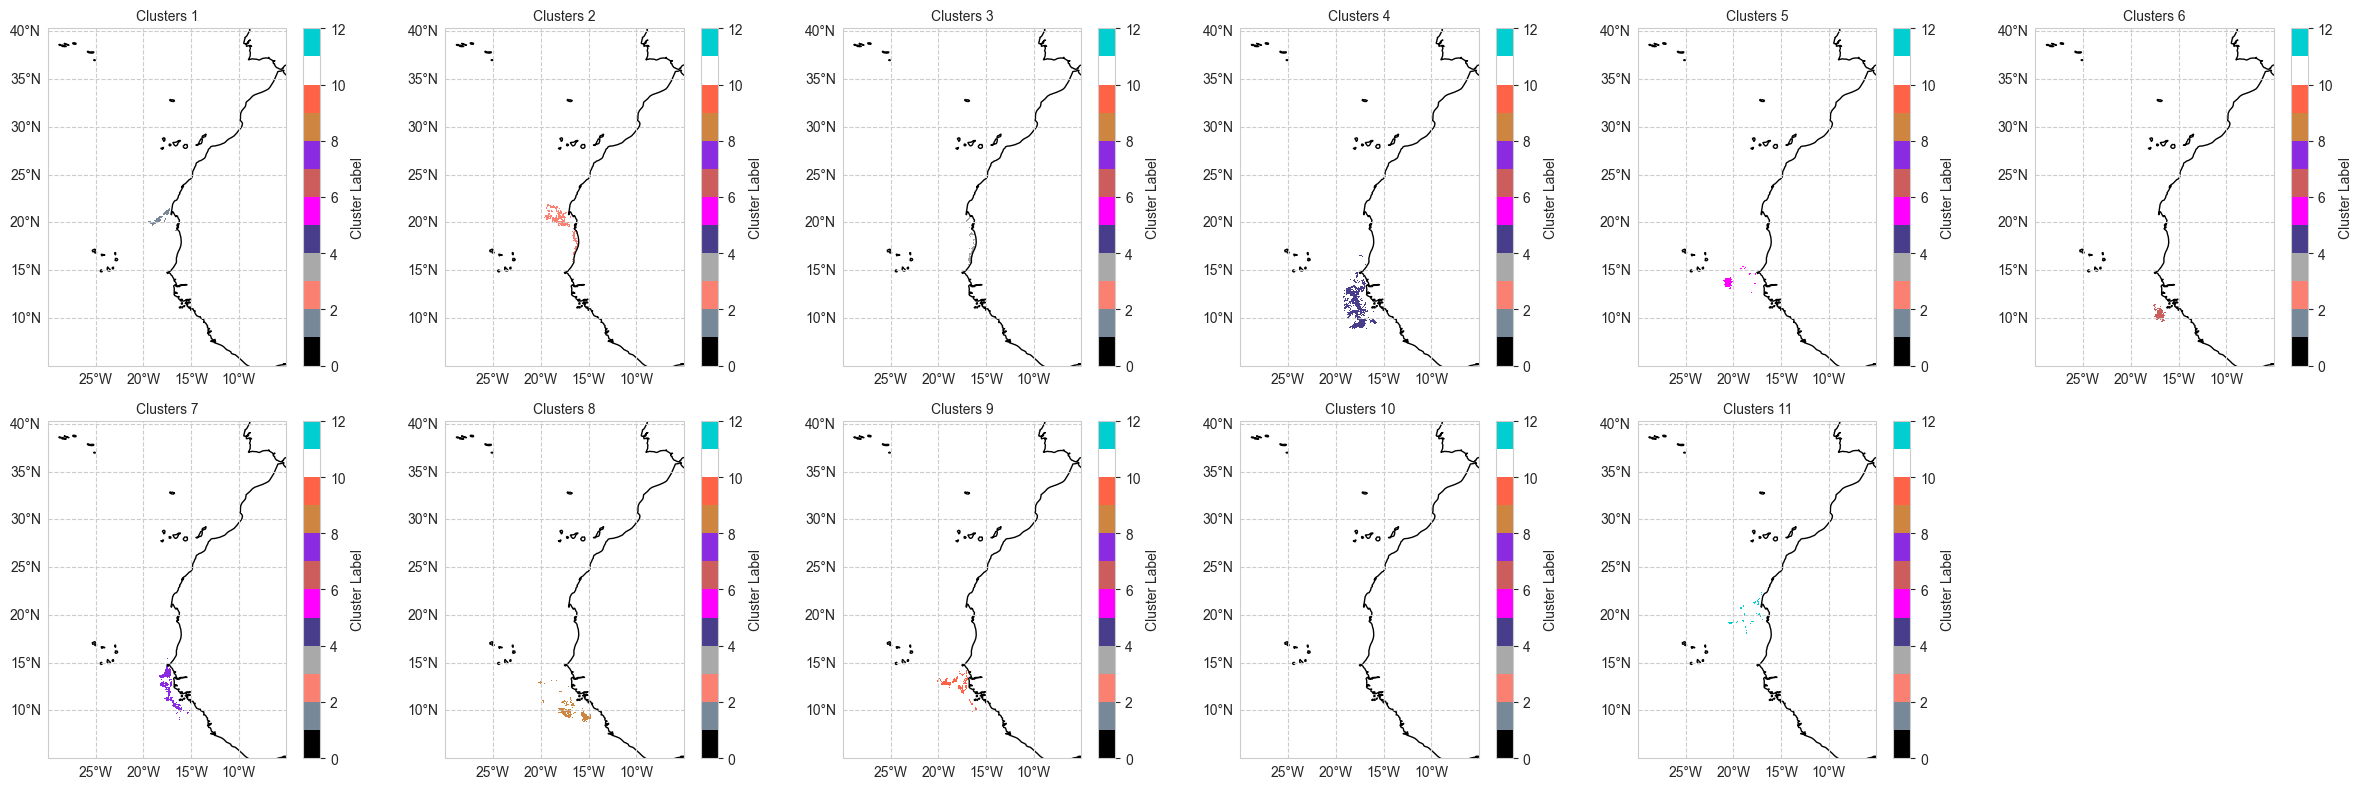

Experiment: (2) Larger Time Eps


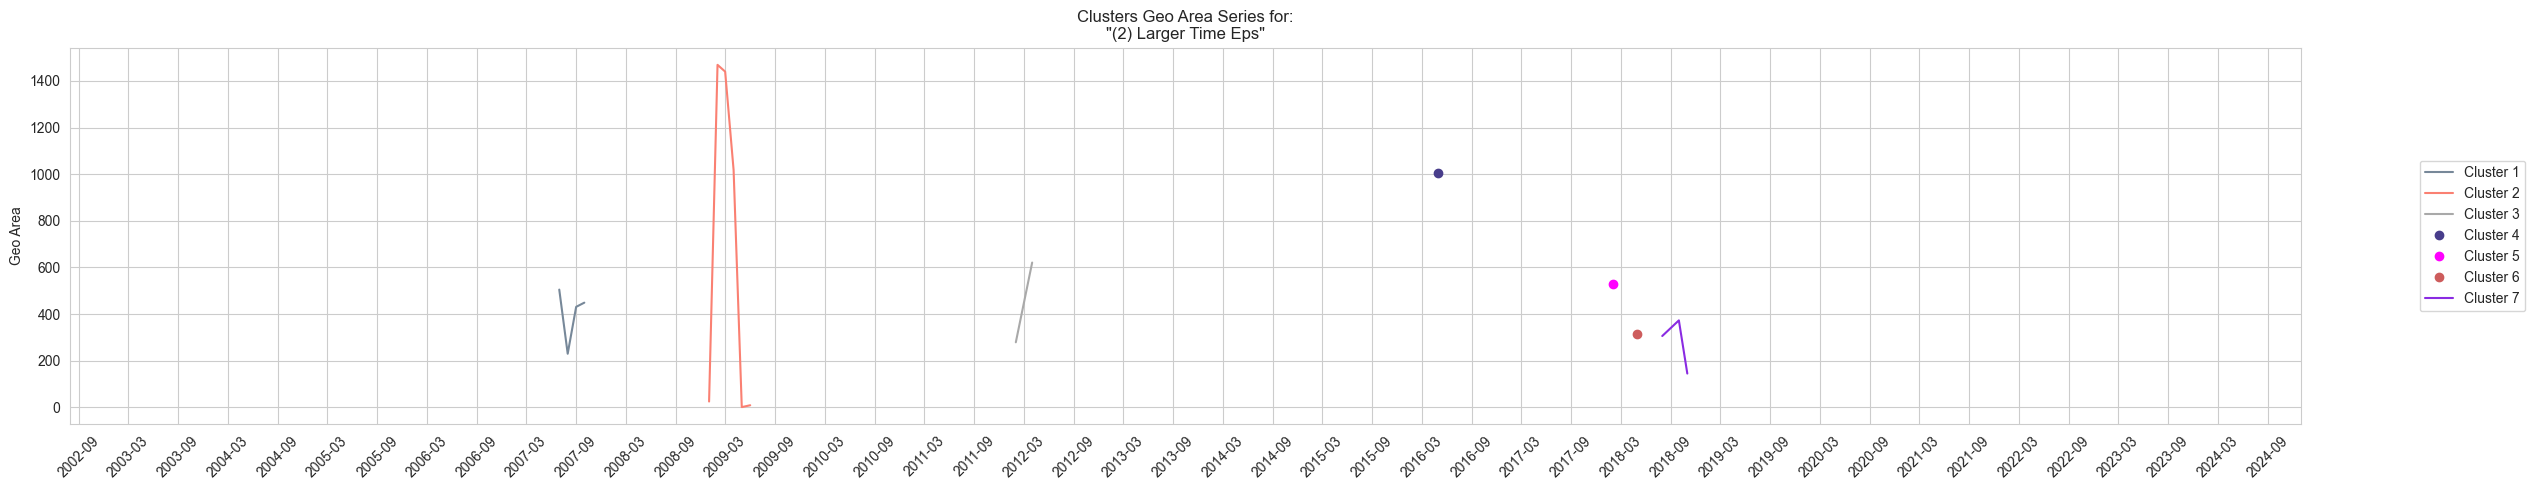

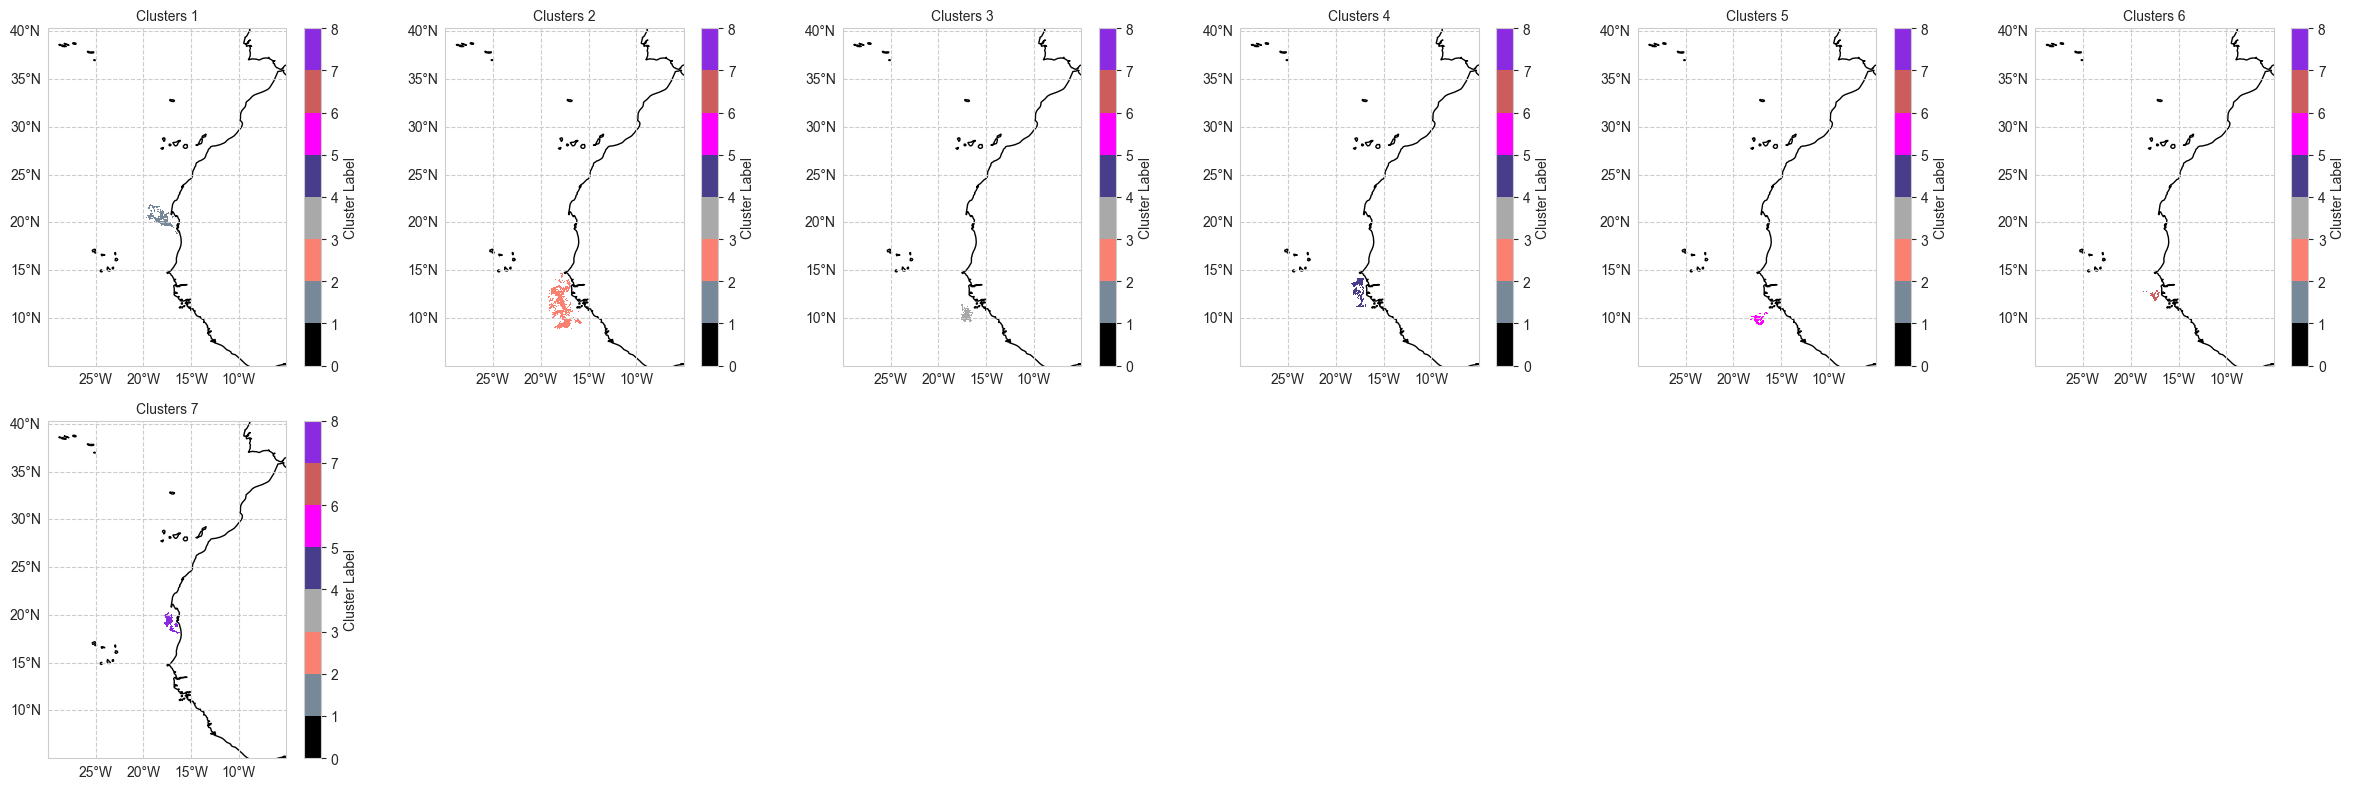

Experiment: (2) Much Larger Time Eps


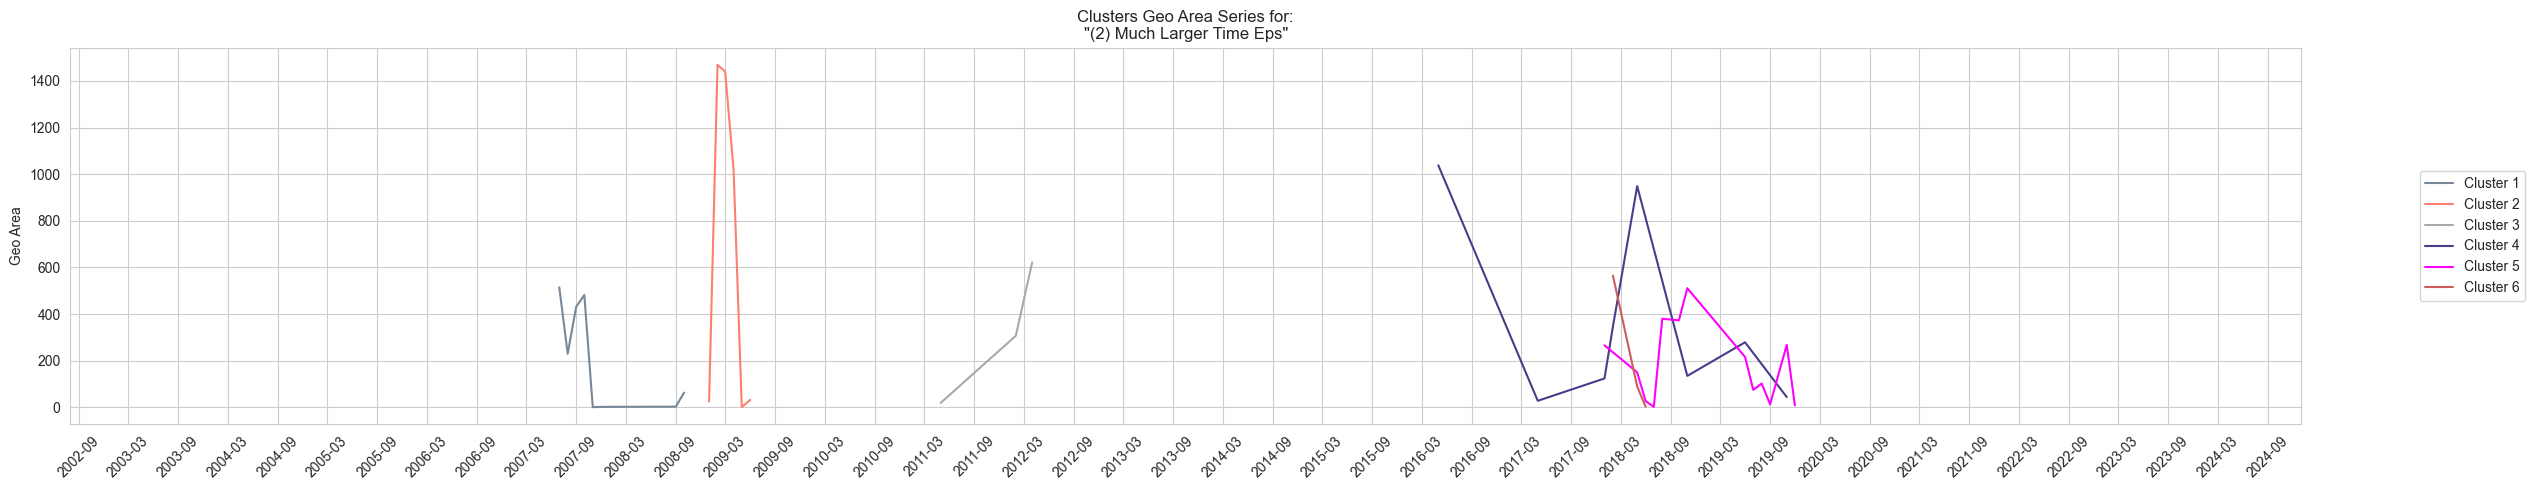

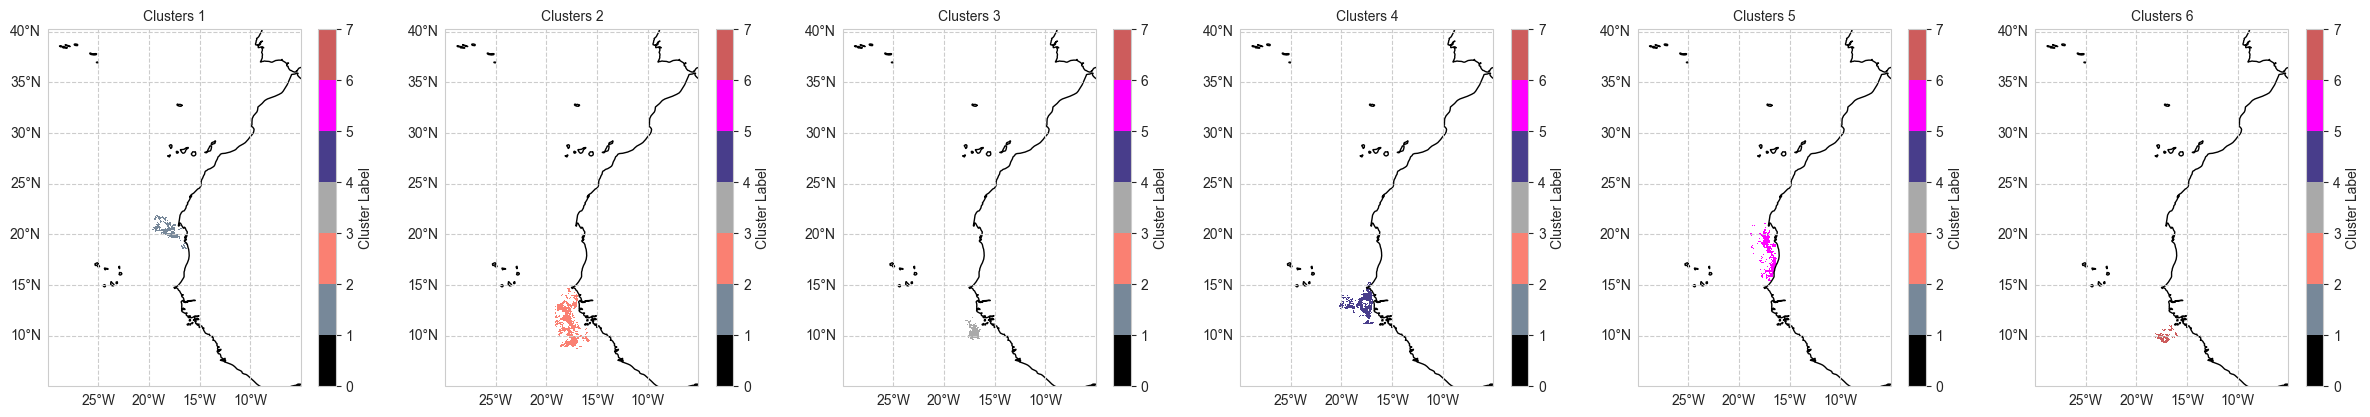

In [160]:
for experiment in experiment_results:
    clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name = experiment
    print(f"Experiment: {experiment_name}")
    
    # Plot the time series of all clusters
    plot_cluster_geo_area_series(clusters, n_clusters, experiment_name)

    # Plot overlay of each cluster in experiment
    plot_individual_cluster_overlay(clusters, n_clusters, experiment_name)

##### Selection

Experiment: Smaller Min Neighbors


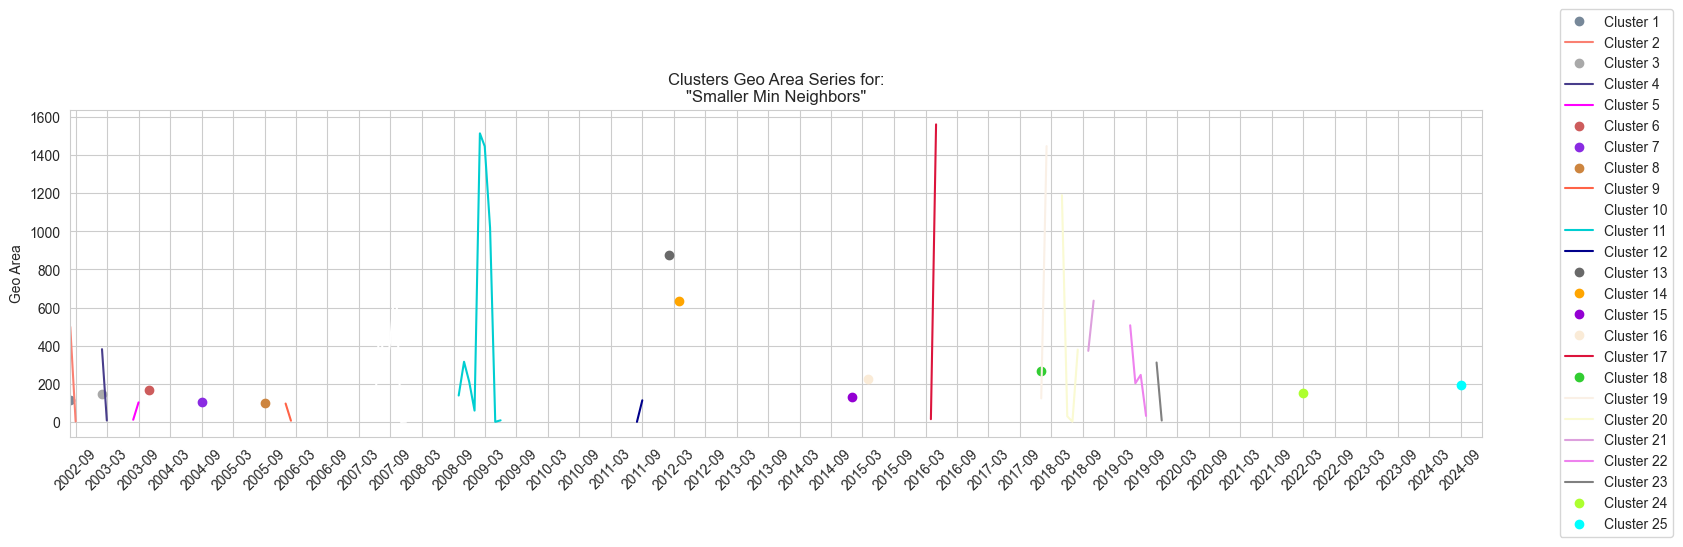

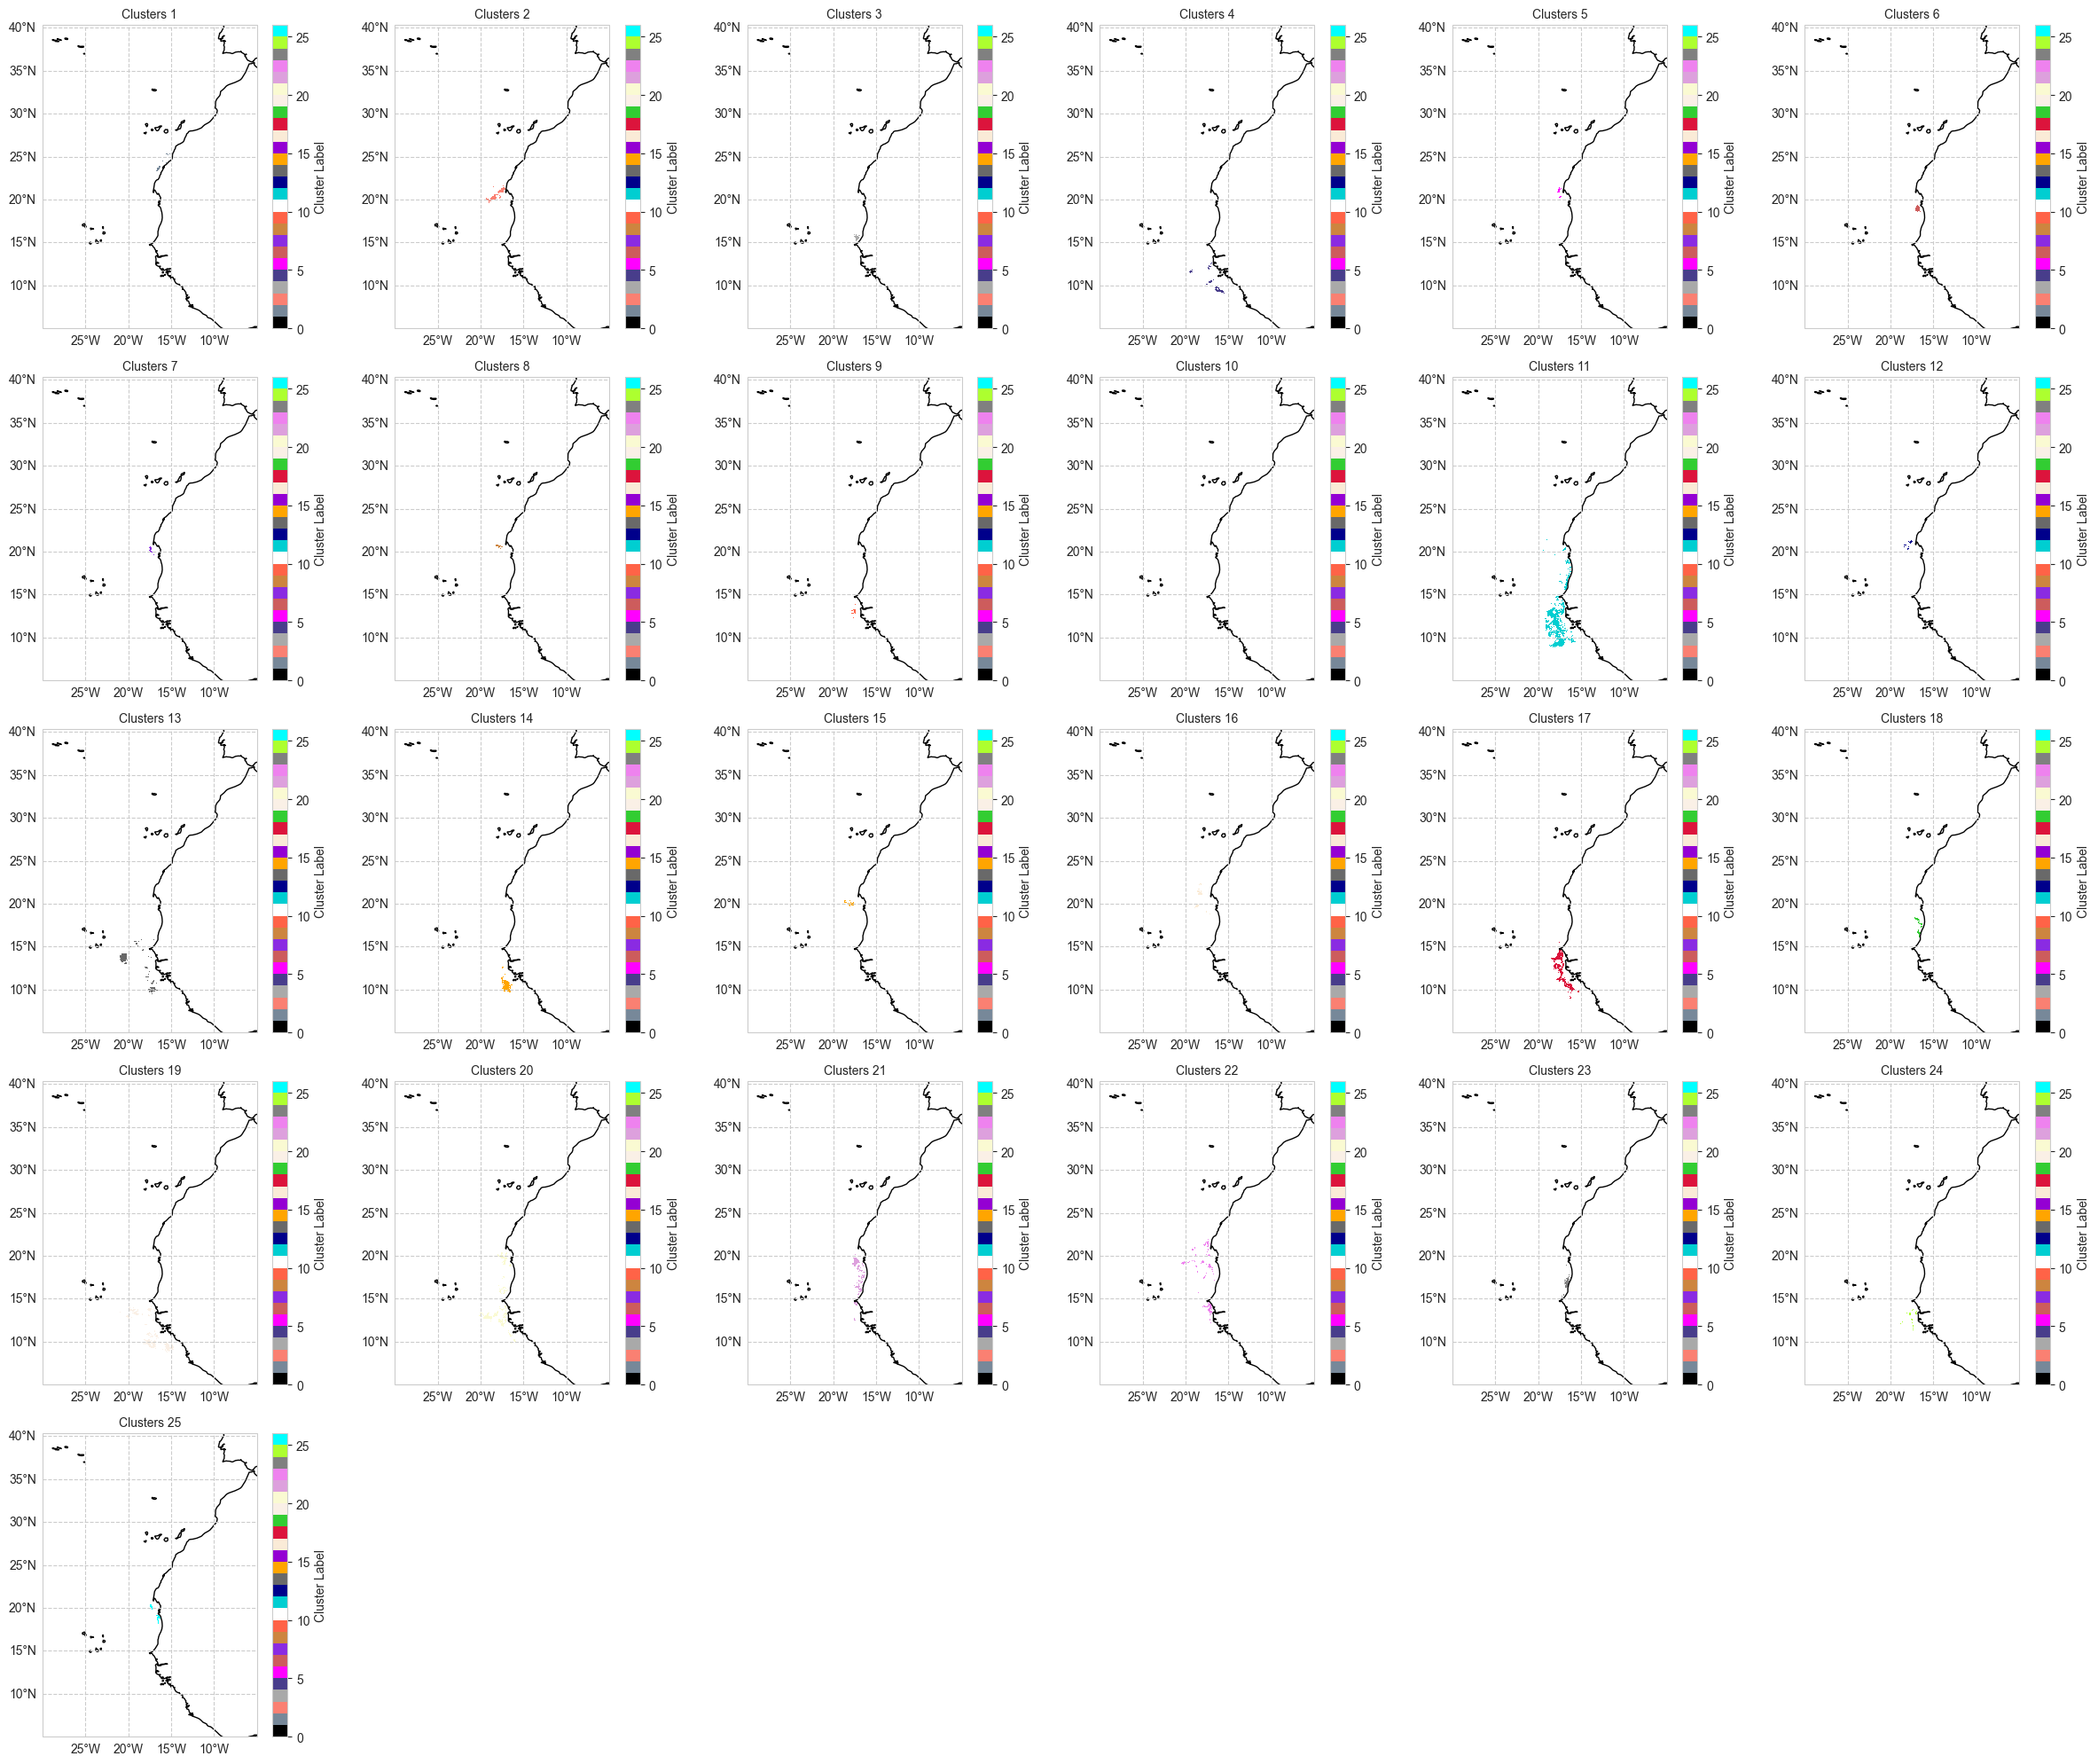

Experiment: (2) Base Full Period


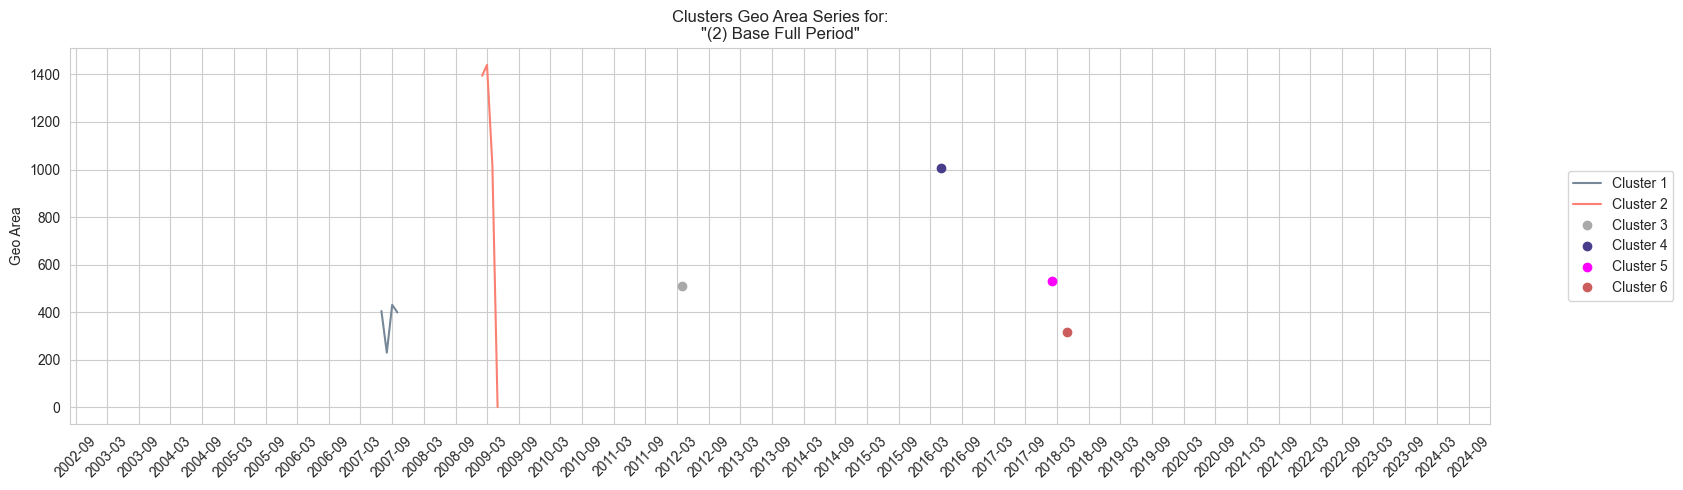

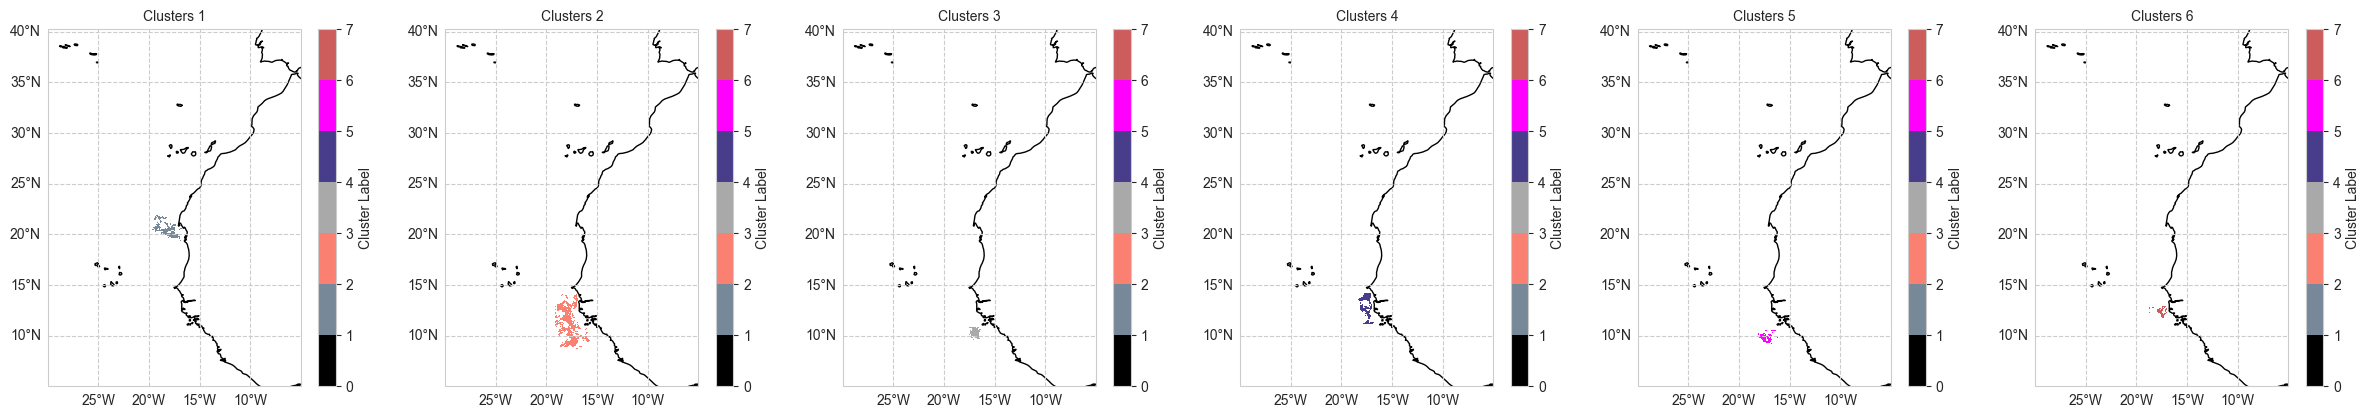

Experiment: (2) Smaller Min Neighbors


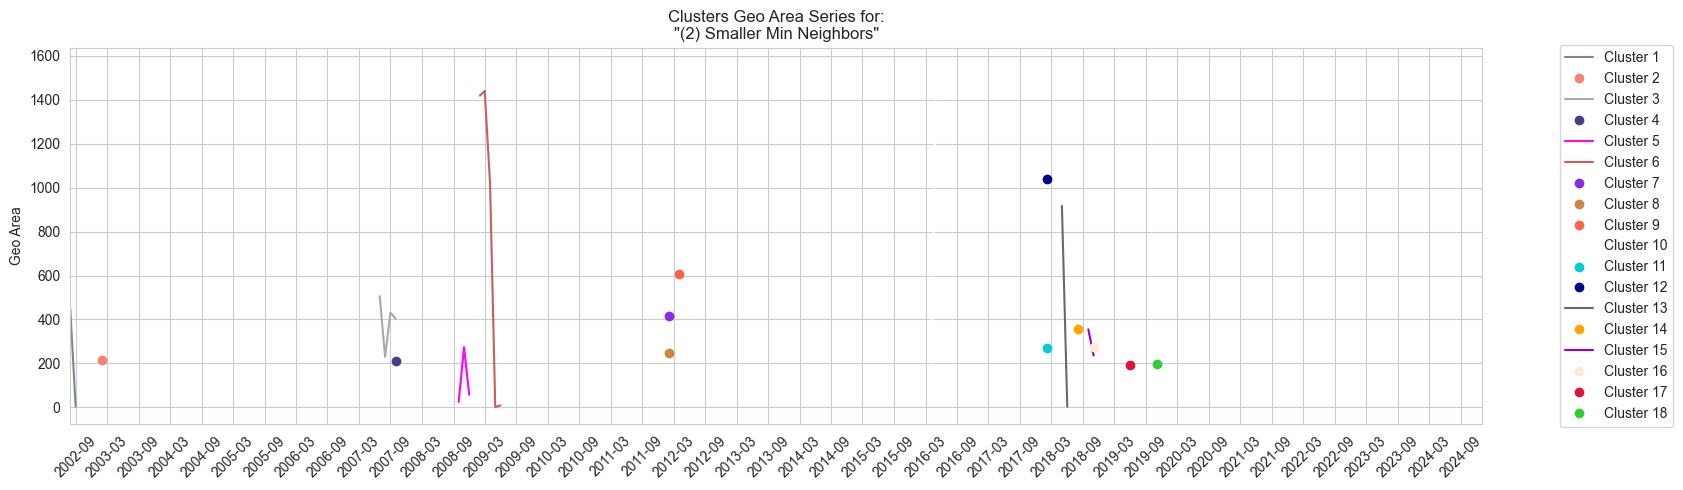

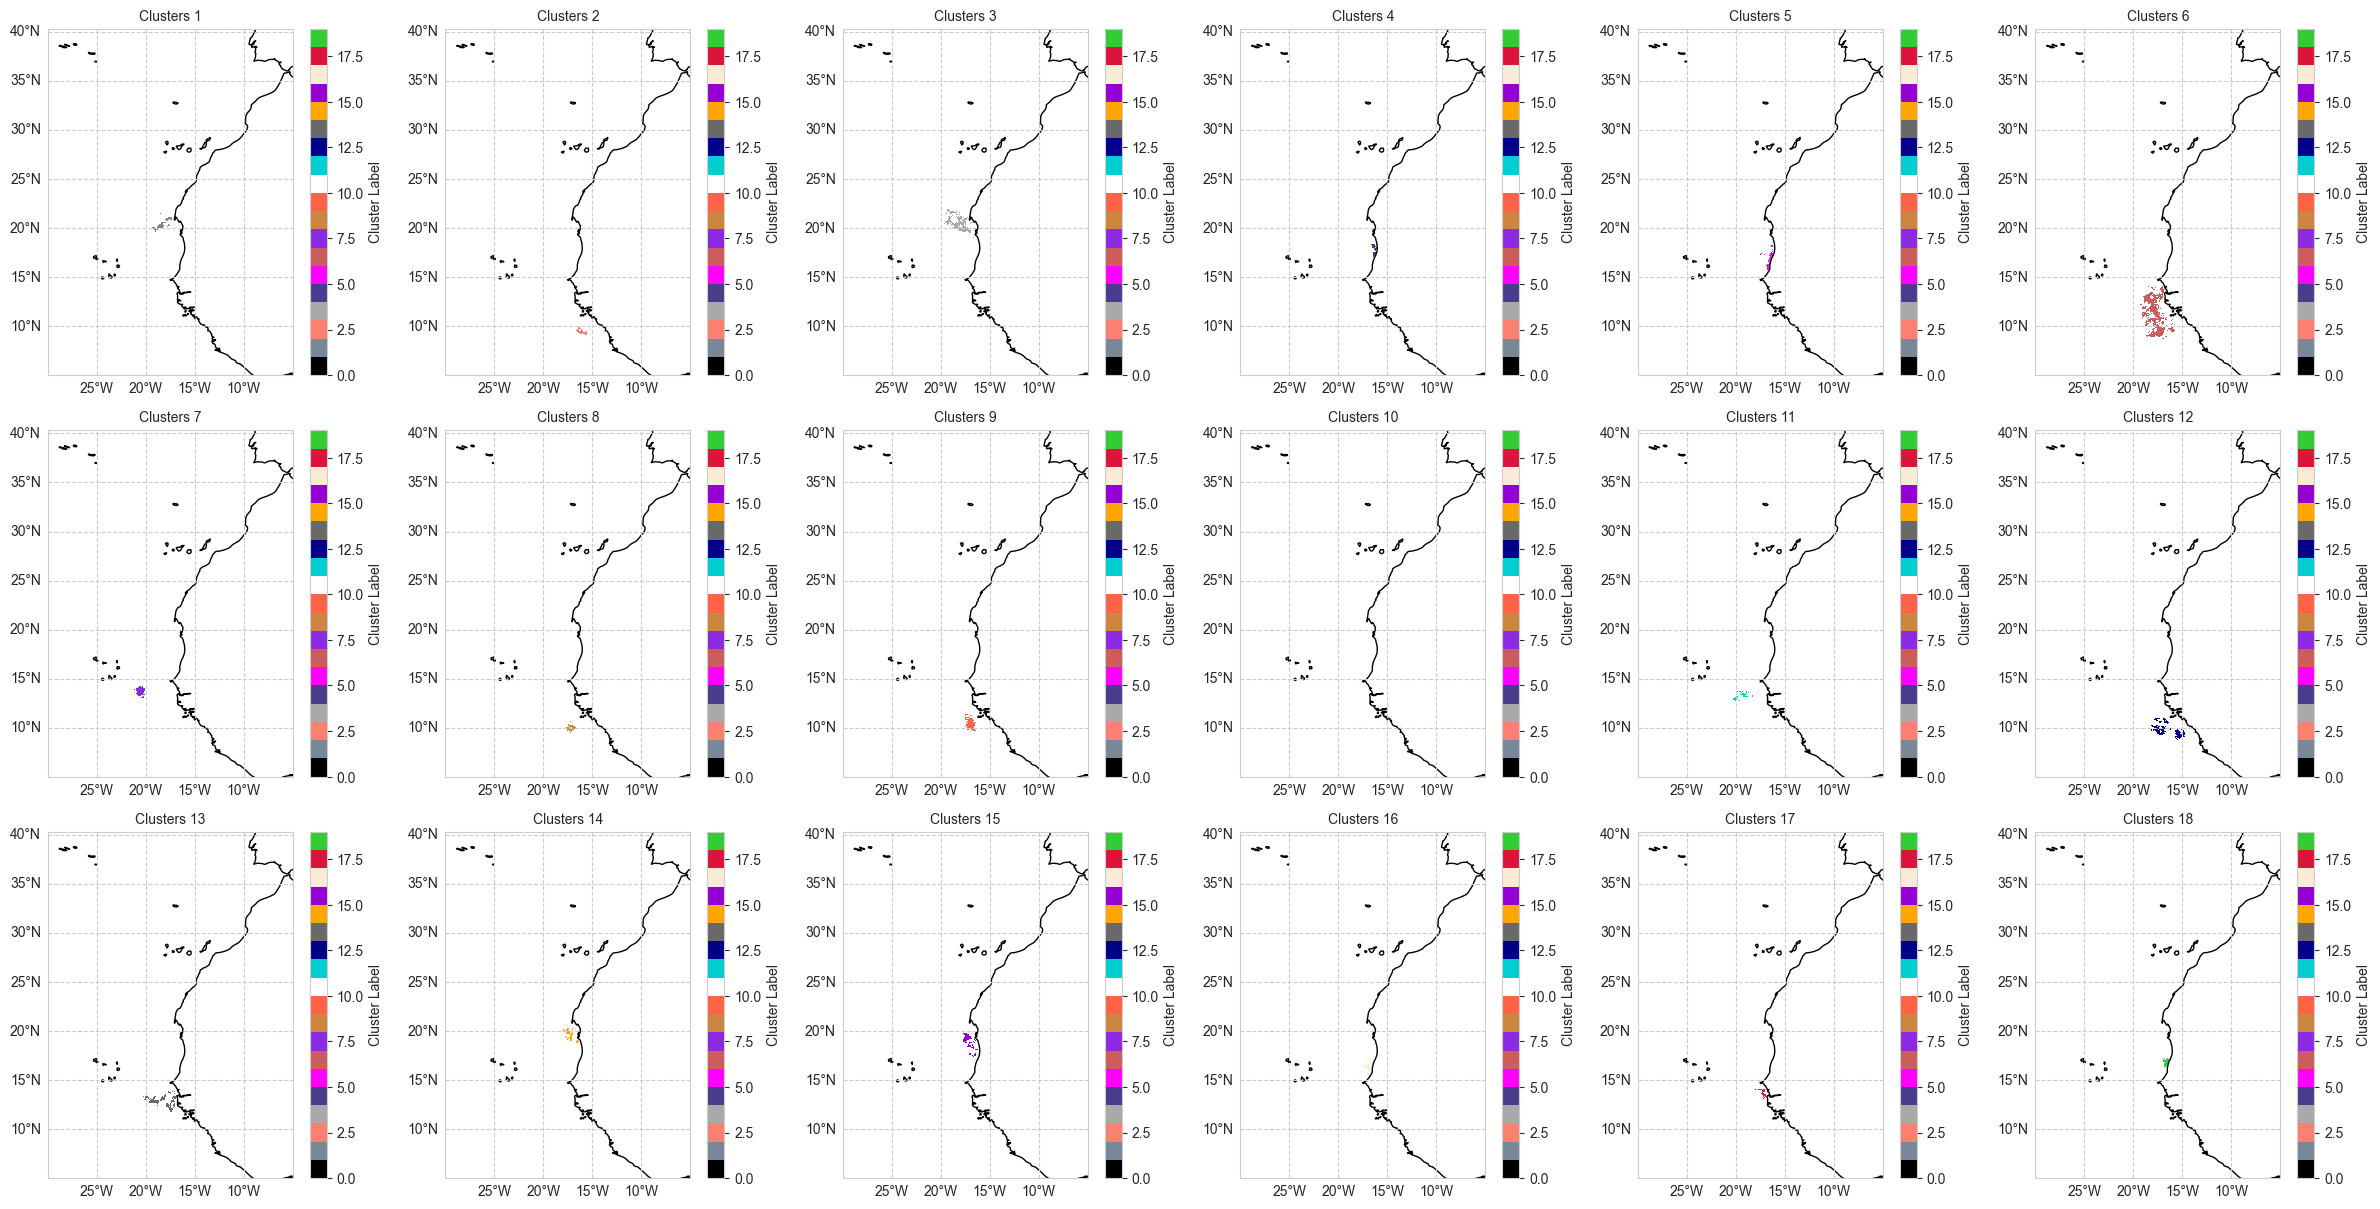

Experiment: (2) Much Larger Time Eps


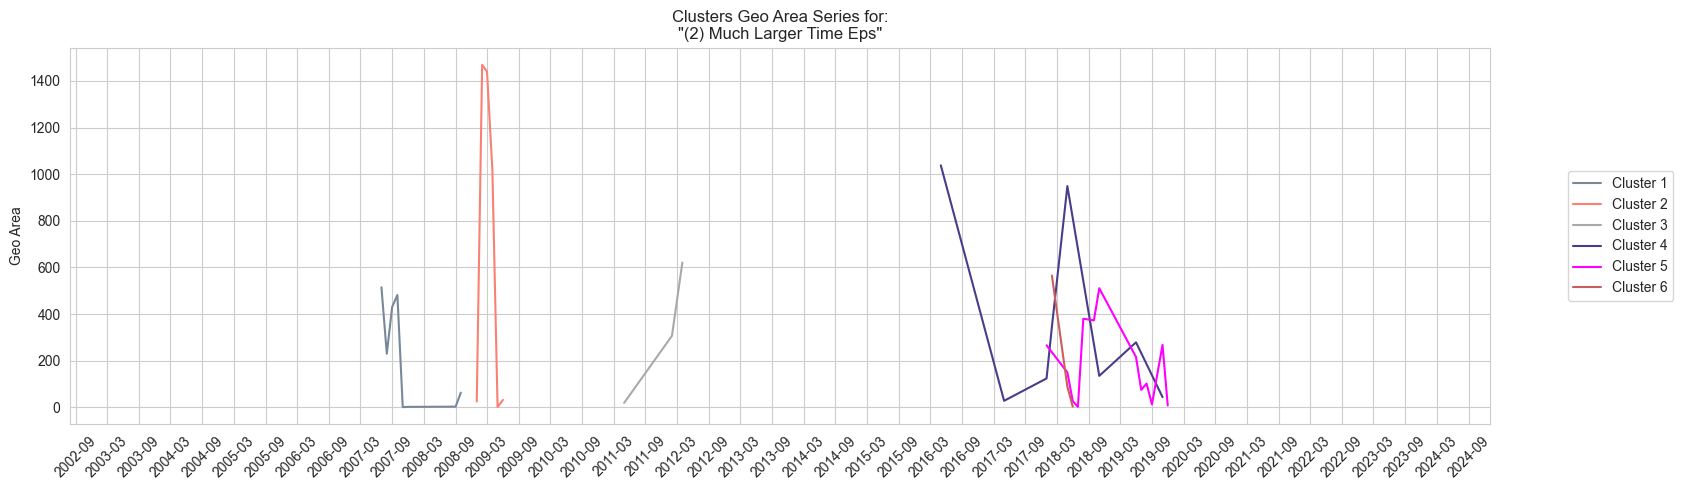

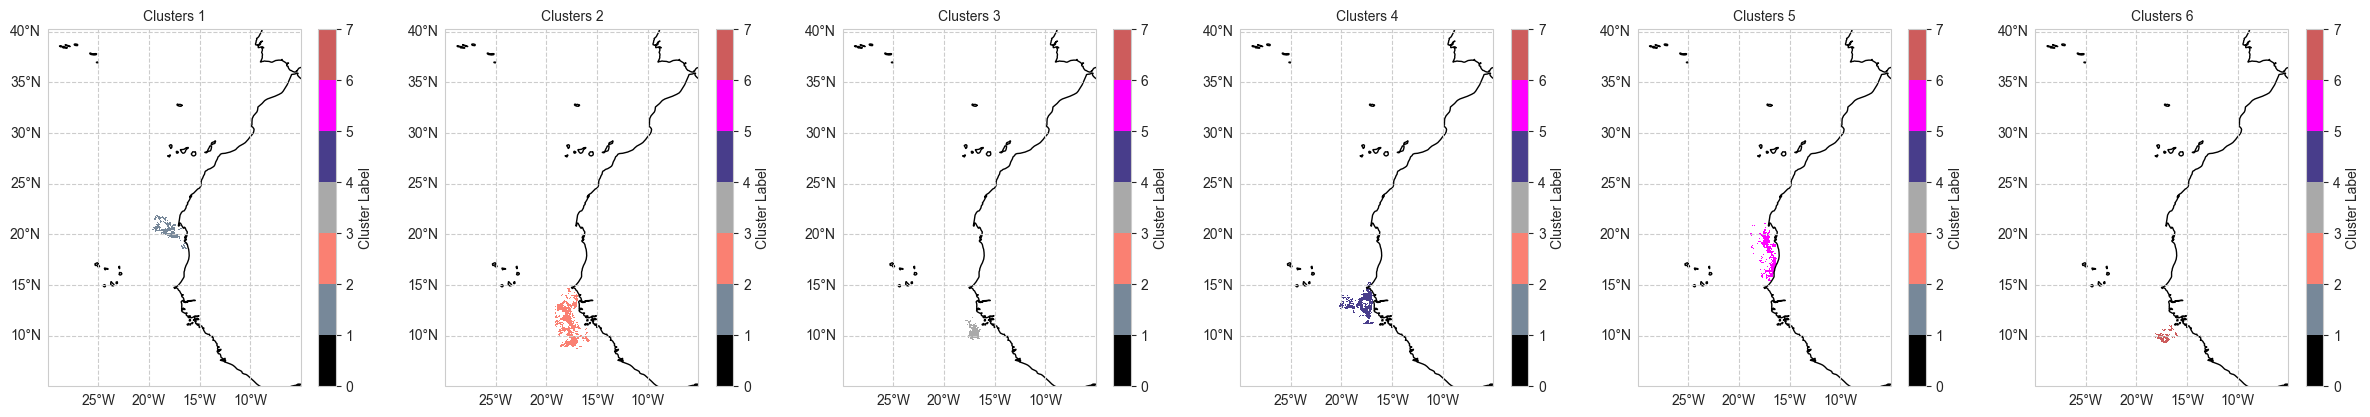

In [177]:
for experiment in experiment_results:
    clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name = experiment
    print(f"Experiment: {experiment_name}")
    
    # Plot the time series of all clusters
    plot_cluster_geo_area_series(clusters, n_clusters, experiment_name)

    # Plot overlay of each cluster in experiment
    plot_individual_cluster_overlay(clusters, n_clusters, experiment_name)

#### Print clusters overlay

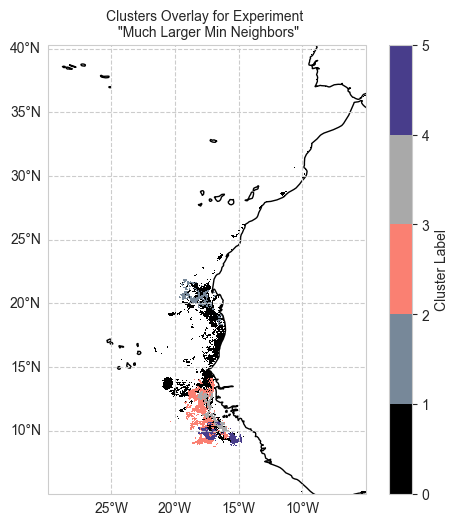

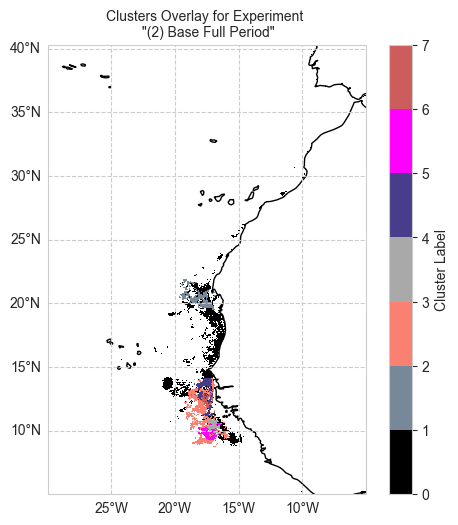

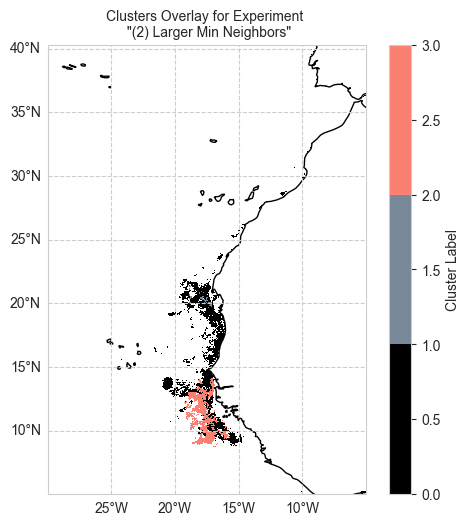

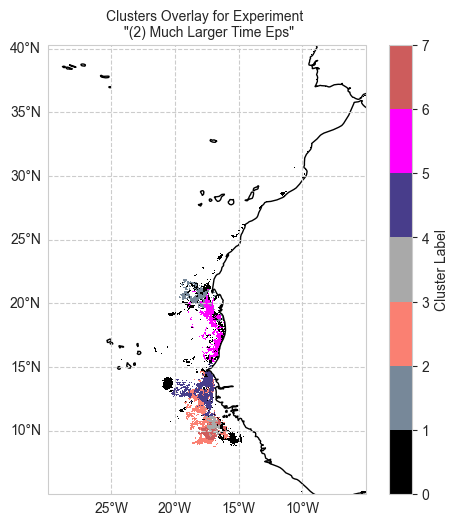

In [129]:
for experiment in experiment_results:
    clusters, n_clusters, n_discarded, run_seconds, file_name, experiment_name = experiment

    # Overlay all clusters into a single image.
    clusters_overlay = clusters.max(dim='time')
    plot_n_spatial_variable(
        [clusters_overlay],
        clusters_overlay.lat,
        clusters_overlay.lon,
        nrows = 2,
        ncols = 4,
        i_width = 5,
        i_height = 5,
        clim=[0, n_clusters+1], 
        titles = [f"Clusters Overlay for Experiment \n \"{experiment_name}\""],
        plot_label = 'Cluster Label',
        cmap = 'labels',
        norm_mode = 'none'
    )